# Craiceann Ice

In this notebook, we combine all the work we have been doing throughout the QAMP project into a single pipeline.

The hope for this is that we demonstrate an interesting application of quantum computing for modelling ice shelf calving that can be extended to modelling real world calving from satelite data.

# Module 1 — Ice-Bond Lattice Construction (Primal Graph)

This module constructs the **primal ice-bond lattice**, which represents the material before fracture.

- **Nodes** correspond to material points arranged on a lattice.
- **Edges** correspond to elastic bonds between neighboring points.
- Fracture is represented later by *breaking edges*.

This lattice is the foundation for:
- mechanics solving (spring network),
- fracture evolution,
- construction of the **dual fracture graph**,
- and catastrophic failure analysis via min-cut.

Only the *geometry and connectivity* are defined here — no physics is solved in this module.

## Geometry and Topology

We use a **square lattice** embedded in 2D space.

- Node indices: `(i, j)`
- Coordinates:
  - `x = i · a`
  - `y = j · a`
- Bond length: `a`

### Boundary conditions
- **Periodic in x** (left ↔ right connected)
- **Non-periodic in y** (top and bottom are physical boundaries)

This makes the lattice topologically equivalent to a **cylinder**, which is important later when defining the dual (fracture) graph.

## Graph Representation

The lattice is stored as a NetworkX **undirected graph**.

### Node attributes
Each node `(i, j)` has:
- `x`: x-coordinate
- `y`: y-coordinate

These are used later for:
- spring directions,
- stress computation,
- visualisation,
- and defining bond angles.

### Edge attributes (bonds)
Each bond has the following attributes:

- `broken : bool`
  - `False` → intact bond  
  - `True` → fractured bond

- `k_mult : float`
  - Multiplicative stiffness factor  
  - `1.0` for intact bonds  
  - `0.0` for broken bonds  
  *(proxy — replaced later by anisotropic / Hamiltonian models)*

- `capacity : float`
  - Used for **min-cut analysis**
  - `1.0` for intact bonds  
  - `0.0` for broken bonds  
  *(interpreted as the “cost” to sever connectivity)*

- `rest_length : float`
  - Geometric rest length of the bond (`a`)

## Assumptions (Current Version)

- Square lattice only
- Identical bonds at build time
- Binary intact/broken state
- No anisotropy
- No material heterogeneity
- No mechanics solved here

This is a **proxy model** designed for clarity and extensibility.

## Planned Extensions

This module is intentionally minimal.

Future upgrades include:
- triangular lattice connectivity,
- spatially varying stiffness (`k_mult`),
- toughness-weighted `capacity`,
- anisotropic bond models,
- Hamiltonian-based fracture energetics,
- and multi-layer / interface lattices.

All future changes preserve the same high-level graph interface.


In [2]:
import networkx as nx
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, Any

Node = Tuple[int, int]
Edge = Tuple[Node, Node]


@dataclass
class IceBondLattice:
    """
    Primal lattice (material graph):
      - nodes: lattice sites (i,j) with embedded coords x,y
      - edges: bonds with state 'broken' and attributes used by later modules
    """
    G: nx.Graph
    nx_nodes: int
    ny_nodes: int
    periodic_x: bool
    a: float = 1.0

    _dual_cache: Optional[Any] = None  # will become FractureDual later

    def invalidate_caches(self):
        self._dual_cache = None
# NOTE:
# The fracture (dual) graph is not stored permanently here.
# It will be derived from the current lattice state when needed
# (e.g. for visualisation or frontier detection) and may be cached
# for performance. Any bond-breaking operation should invalidate
# this cache so derived graphs are always consistent.


def build_square_lattice_periodic_x(
    nx_nodes: int,
    ny_nodes: int,
    periodic_x: bool = True,
    a: float = 1.0
) -> IceBondLattice:
    """
    Build a square lattice with optional x-periodic wrapping.

    Nodes:
      (i,j) for i=0..nx_nodes-1, j=0..ny_nodes-1
      node attrs: x, y

    Edges (bonds):
      horizontal: (i,j)-(i+1,j), wrapping to (0,j) if periodic_x and i=nx_nodes-1
      vertical:   (i,j)-(i,j+1) for j < ny_nodes-1

    Edge attrs:
      broken: bool (default False)
      k_mult: float (default 1.0; becomes 0.0 when broken)
      capacity: float (default 1.0; becomes 0.0 when broken; later toughness)
      rest_length: float (default a)
    """
    if nx_nodes < 2 or ny_nodes < 2:
        raise ValueError("Need at least 2x2 nodes to form a meaningful lattice.")

    G = nx.Graph()

    # Add nodes with embedded coordinates
    for i in range(nx_nodes):
        for j in range(ny_nodes):
            G.add_node((i, j), x=a * i, y=a * j)

    def add_bond(u: Node, v: Node):
        # Avoid duplicates (Graph will overwrite anyway, but be explicit)
        if G.has_edge(u, v):
            return
        G.add_edge(
            u, v,
            broken=False,
            k_mult=1.0,
            capacity=1.0,
            rest_length=a
        )

    # Horizontal bonds (+x direction), with optional wrap
    for i in range(nx_nodes):
        for j in range(ny_nodes):
            ip1 = i + 1
            if ip1 < nx_nodes:
                add_bond((i, j), (ip1, j))
            elif periodic_x:
                add_bond((i, j), (0, j))

    # Vertical bonds (+y direction), no wrap
    for i in range(nx_nodes):
        for j in range(ny_nodes - 1):
            add_bond((i, j), (i, j + 1))

    lattice = IceBondLattice(G=G, nx_nodes=nx_nodes, ny_nodes=ny_nodes, periodic_x=periodic_x, a=a)
    return lattice


### validate via lil demo

In [3]:
def validate_lattice(lattice: IceBondLattice) -> Dict[str, Any]:
    G = lattice.G
    nx_nodes = lattice.nx_nodes
    ny_nodes = lattice.ny_nodes

    # 1) periodic edge existence check
    periodic_ok = True
    if lattice.periodic_x:
        for j in range(ny_nodes):
            if not G.has_edge((nx_nodes - 1, j), (0, j)):
                periodic_ok = False
                break

    # 2) edge attribute sanity
    attrs_ok = True
    required_edge_attrs = {"broken", "k_mult", "capacity", "rest_length"}
    for (_, _, d) in G.edges(data=True):
        if not required_edge_attrs.issubset(d.keys()):
            attrs_ok = False
            break

    # 3) node attribute sanity
    node_ok = True
    for (_, d) in G.nodes(data=True):
        if "x" not in d or "y" not in d:
            node_ok = False
            break

    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "periodic_ok": periodic_ok,
        "edge_attrs_ok": attrs_ok,
        "node_attrs_ok": node_ok,
        "nx_nodes": nx_nodes,
        "ny_nodes": ny_nodes,
        "periodic_x": lattice.periodic_x,
        "a": lattice.a,
    }


# Tiny demo
lat = build_square_lattice_periodic_x(nx_nodes=6, ny_nodes=4, periodic_x=True, a=1.0)
report = validate_lattice(lat)
report


{'nodes': 24,
 'edges': 42,
 'periodic_ok': True,
 'edge_attrs_ok': True,
 'node_attrs_ok': True,
 'nx_nodes': 6,
 'ny_nodes': 4,
 'periodic_x': True,
 'a': 1.0}

# Module 2 — Breaking Bonds and Initial Fracture Inputs

This module defines how **fracture** is represented in the primal ice-bond lattice.

A fracture is modeled as a set of **broken bonds** (edges). We do **not** delete edges from the graph. Instead, we keep them for:

- geometry (so we can plot the original lattice),
- building the **dual (fracture) graph** later,
- defining the crack frontier near existing breaks,
- and consistent bookkeeping for public reproducibility.

## Edge state convention

Each bond (edge) carries these attributes:

- `broken : bool`  
  `False` → intact, `True` → fractured

- `k_mult : float`  
  stiffness multiplier used later in the mechanics solver  
  `1.0` intact, `0.0` broken  
  *(proxy — later replaced by richer physics, e.g. anisotropy / Hamiltonian methods)*

- `capacity : float`  
  connectivity weight used later for min-cut catastrophic failure analysis  
  `1.0` intact, `0.0` broken  
  *(proxy — later can represent toughness / heterogeneous resistance)*

We enforce the invariant:

> If `broken=True` then `k_mult=0` and `capacity=0`.

## Initial fracture inputs

Two supported input styles:

1. **Edge list (explicit):** a list of bonds `[(u,v), ...]` to break directly.  
2. **Seed-based (high-level, later):** a notch/crack described by a seed node and a direction/length.  
   This generates an edge list internally.

This module implements (1) now, and provides a simple “band cut” initializer for early validation.


In [4]:
from typing import Iterable, List

Node = Tuple[int, int]
Edge = Tuple[Node, Node]


def canonical_edge(u: Node, v: Node) -> Edge:
    """Canonical ordering for an undirected edge (u,v)."""
    return (u, v) if u <= v else (v, u)


def _get_edge_data(G: nx.Graph, u: Node, v: Node) -> Dict[str, Any]:
    if not G.has_edge(u, v):
        raise KeyError(f"Edge {u}-{v} not found in lattice.")
    return G[u][v]


def break_edge(lattice, u: Node, v: Node) -> None:
    """
    Break a single bond (irreversible).
    Keeps the edge in the graph but disables mechanics + connectivity proxies.
    """
    d = _get_edge_data(lattice.G, u, v)

    # Irreversible: if already broken, just keep it broken (no error).
    d["broken"] = True
    d["k_mult"] = 0.0
    d["capacity"] = 0.0

    # Any derived structures (e.g., dual graph) become stale after mutation.
    if hasattr(lattice, "invalidate_caches"):
        lattice.invalidate_caches()


def break_edges(lattice, edges: Iterable[Edge]) -> None:
    """Break multiple bonds (irreversible)."""
    for (u, v) in edges:
        break_edge(lattice, u, v)


def is_broken(lattice, u: Node, v: Node) -> bool:
    """Check whether a bond is broken."""
    return bool(_get_edge_data(lattice.G, u, v).get("broken", False))


def intact_edges(lattice) -> List[Edge]:
    """Return list of intact edges."""
    out: List[Edge] = []
    for u, v, d in lattice.G.edges(data=True):
        if not d.get("broken", False):
            out.append(canonical_edge(u, v))
    return out


def broken_edges(lattice) -> List[Edge]:
    """Return list of broken edges."""
    out: List[Edge] = []
    for u, v, d in lattice.G.edges(data=True):
        if d.get("broken", False):
            out.append(canonical_edge(u, v))
    return out


def fracture_summary(lattice) -> Dict[str, int]:
    """Quick fracture state summary."""
    n_broken = 0
    for _, _, d in lattice.G.edges(data=True):
        if d.get("broken", False):
            n_broken += 1
    total = lattice.G.number_of_edges()
    return {
        "broken_edges": n_broken,
        "intact_edges": total - n_broken,
        "total_edges": total,
    }


def validate_break_invariants(lattice) -> bool:
    """
    Lightweight invariant check:
      - broken=True => k_mult=0 and capacity=0
      - broken=False => k_mult>0 and capacity>0
    """
    for _, _, d in lattice.G.edges(data=True):
        broken = bool(d.get("broken", False))
        k_mult = float(d.get("k_mult", 1.0))
        cap = float(d.get("capacity", 1.0))

        if broken:
            if not (k_mult == 0.0 and cap == 0.0):
                return False
        else:
            if not (k_mult > 0.0 and cap > 0.0):
                return False
    return True


### validate via  mini demo

In [5]:
def band_cut_edges(lattice, j_cut: int) -> List[Edge]:
    """
    Return all vertical edges crossing between rows j_cut and j_cut+1:
      (i, j_cut) -- (i, j_cut+1) for all i.
    """
    if not (0 <= j_cut < lattice.ny_nodes - 1):
        raise ValueError("j_cut must satisfy 0 <= j_cut < ny_nodes-1")

    edges: List[Edge] = []
    for i in range(lattice.nx_nodes):
        u = (i, j_cut)
        v = (i, j_cut + 1)
        if lattice.G.has_edge(u, v):
            edges.append(canonical_edge(u, v))
    return edges

# Demo
lat = build_square_lattice_periodic_x(nx_nodes=10, ny_nodes=8, periodic_x=True, a=1.0)

print("Before:", fracture_summary(lat))

edges = band_cut_edges(lat, j_cut=3)
break_edges(lat, edges)

print("After:", fracture_summary(lat))
print("Break invariants OK?", validate_break_invariants(lat))
print("Periodic OK?", validate_lattice(lat)["periodic_ok"])


Before: {'broken_edges': 0, 'intact_edges': 150, 'total_edges': 150}
After: {'broken_edges': 10, 'intact_edges': 140, 'total_edges': 150}
Break invariants OK? True
Periodic OK? True


# Module 3 — Dual Graph and Fracture Representation

This module constructs the **dual graph** of the ice-bond lattice.

- The **primal graph** describes material bonds.
- The **dual graph** describes the regions (faces) separated by those bonds.

A broken bond activates the corresponding **dual edge**, so cracks are represented
naturally as paths in the dual.

## Why use the dual?
Fracture separates regions of material. In a lattice model, this separation is
encoded cleanly in the dual:
- primal edges = bonds you break
- dual edges = crack segments

## Topology
The lattice is:
- periodic in x
- open in y

Topologically, this is a **cylinder**.

To ensure every bond has two adjacent faces, we introduce two outer faces:
- `("outer","bottom")`
- `("outer","top")`

## Face convention
Each square cell face is identified by its bottom-left node:

    ("cell", i, j)

Outer faces represent regions outside the lattice in the y-direction.

## Output
This module provides:
1. the **full dual graph** (all bonds),
2. the **fracture dual graph**, containing only edges corresponding to broken bonds.


In [6]:
import math

def _wrap_i(lattice, i: int) -> int:
    return i % lattice.nx_nodes


CELL = "cell"
OUTER = "outer"

BOTTOM_OUT = (OUTER, "bottom")
TOP_OUT = (OUTER, "top")


def cell_face(i: int, j: int):
    return (CELL, i, j)


def list_all_faces(lattice):
    faces = []
    for i in range(lattice.nx_nodes):
        for j in range(lattice.ny_nodes - 1):
            faces.append(cell_face(i, j))
    faces.append(BOTTOM_OUT)
    faces.append(TOP_OUT)
    return faces

def primal_edge_phi(lattice, u, v) -> float:
    x1, y1 = lattice.G.nodes[u]["x"], lattice.G.nodes[u]["y"]
    x2, y2 = lattice.G.nodes[v]["x"], lattice.G.nodes[v]["y"]
    return math.atan2(y2 - y1, x2 - x1)

def adjacent_faces_for_primal_edge(lattice, u, v):
    (i1, j1), (i2, j2) = u, v

    # Horizontal bond
    if j1 == j2:
        j = j1

        # identify left index (handles periodic wrap)
        if _wrap_i(lattice, i1 + 1) == i2:
            i_left = i1
        elif _wrap_i(lattice, i2 + 1) == i1:
            i_left = i2
        else:
            raise ValueError(f"Invalid horizontal bond: {u}-{v}")

        # above face
        if j == lattice.ny_nodes - 1:
            face_above = TOP_OUT
        else:
            face_above = cell_face(i_left, j)

        # below face
        if j == 0:
            face_below = BOTTOM_OUT
        else:
            face_below = cell_face(i_left, j - 1)

        return face_above, face_below

    # Vertical bond
    if i1 == i2:
        i = i1

        if j2 == j1 + 1:
            j_low = j1
        elif j1 == j2 + 1:
            j_low = j2
        else:
            raise ValueError(f"Invalid vertical bond: {u}-{v}")

        face_a = cell_face(i, j_low)
        face_b = cell_face(_wrap_i(lattice, i - 1), j_low)

        return face_a, face_b

    raise ValueError(f"Non-axis-aligned bond: {u}-{v}")

def build_dual_graph(lattice):
    D = nx.Graph()

    for f in list_all_faces(lattice):
        D.add_node(f)

    for u, v in lattice.G.edges():
        f1, f2 = adjacent_faces_for_primal_edge(lattice, u, v)
        pe = canonical_edge(u, v)

        D.add_edge(
            f1, f2,
            primal_edge=pe,
            phi=primal_edge_phi(lattice, pe[0], pe[1])
        )

    return D

def build_fracture_dual_graph(lattice):
    F = nx.Graph()

    for f in list_all_faces(lattice):
        F.add_node(f)

    for u, v, d in lattice.G.edges(data=True):
        if d.get("broken", False):
            f1, f2 = adjacent_faces_for_primal_edge(lattice, u, v)
            pe = canonical_edge(u, v)

            F.add_edge(
                f1, f2,
                primal_edge=pe,
                phi=primal_edge_phi(lattice, pe[0], pe[1])
            )

    return F


In [7]:
def validate_dual_consistency(lattice):
    D = build_dual_graph(lattice)
    broken = broken_edges(lattice)
    F = build_fracture_dual_graph(lattice)

    return {
        "primal_edges": lattice.G.number_of_edges(),
        "dual_edges": D.number_of_edges(),
        "broken_primal_edges": len(broken),
        "fracture_dual_edges": F.number_of_edges(),
        "dual_edge_count_ok": D.number_of_edges() == lattice.G.number_of_edges(),
        "fracture_edge_count_ok": F.number_of_edges() == len(broken),
    }


# quick sanity demo
lat = build_square_lattice_periodic_x(6, 5, periodic_x=True)
break_edges(lat, band_cut_edges(lat, j_cut=2))

validate_dual_consistency(lat)


{'primal_edges': 54,
 'dual_edges': 54,
 'broken_primal_edges': 6,
 'fracture_dual_edges': 6,
 'dual_edge_count_ok': True,
 'fracture_edge_count_ok': True}

# Module 4 — Visualisation (Primal + Fracture Dual Overlay)

This module provides plotting utilities for:

1) the **primal ice-bond lattice** (nodes + bonds), with broken bonds immediately obvious  
2) the **fracture dual graph** (active dual edges only)  
3) an **overlay plot**: fracture dual drawn on top of a faded primal lattice so it’s clear where cracks come from

## Design goals
- Broken bonds must “pop”: **red + dashed**.
- Primal lattice edges should be relatively thin; primal nodes should be visible and slightly larger.
- The fracture dual should be overlaid on a **faded** primal lattice.
- Only **active** dual nodes (incident to fracture edges) are shown, and they are **red**.
- Plots should be visually clean: **no outer box**, **no ticks**, just subtle **x** and **y** labels.

## Future extension
- Optional `edge_scalar` overlays (e.g., stress/energy from mechanics) can colour intact bonds once Module F exists.
- Later modules can overlay min-cut edges and/or frontier edges for debugging.


In [8]:
# Module 4 plotting backend
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

def _style_axes_minimal(ax, xlabel="x", ylabel="y"):
    """Remove the outer box/ticks and keep subtle axis labels only."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=10)
    # nudge labels slightly outward
    ax.xaxis.set_label_coords(0.5, -0.03)
    ax.yaxis.set_label_coords(-0.03, 0.5)


def _node_pos(lattice):
    """Return dict node -> (x,y)."""
    return {n: (lattice.G.nodes[n]["x"], lattice.G.nodes[n]["y"]) for n in lattice.G.nodes()}


def _is_wrap_horizontal(lattice, u, v) -> bool:
    """True if edge is the x-periodic wrap edge between i=nx-1 and i=0 on same row."""
    (i1, j1), (i2, j2) = u, v
    if j1 != j2:
        return False
    return abs(i1 - i2) == (lattice.nx_nodes - 1)


def _edge_segments_primal(lattice, u, v):
    """
    Return list of line segments for drawing a primal edge (u,v).
    For wrap edges, return two boundary segments (clean periodic-x rendering).
    """
    a = lattice.a
    pos = _node_pos(lattice)
    (x1, y1) = pos[u]
    (x2, y2) = pos[v]

    x_left = -0.5 * a
    x_right = (lattice.nx_nodes - 1) * a + 0.5 * a

    if lattice.periodic_x and _is_wrap_horizontal(lattice, u, v):
        # choose right-side endpoint vs left-side endpoint
        if x1 > x2:
            xr, yr = x1, y1
            xl, yl = x2, y2
        else:
            xr, yr = x2, y2
            xl, yl = x1, y1

        return [
            [(xr, yr), (x_right, yr)],
            [(x_left, yl), (xl, yl)],
        ]

    return [[(x1, y1), (x2, y2)]]


def _canonical_edge(u, v):
    return (u, v) if u <= v else (v, u)

def plot_primal_lattice(
    lattice,
    edge_scalar=None,
    scalar_label="edge scalar",
    show_nodes=True,
    node_size=35,          # bigger nodes
    intact_lw=0.9,         # thinner lines
    broken_lw=0.9,         # same thickness as intact (difference is style/color)
    intact_alpha=0.8,
    title=None,
):
    """
    Plot the primal lattice:
      - intact edges: solid (optionally coloured by edge_scalar)
      - broken edges: red dashed
      - nodes: visible markers
      - wrap edges are split into boundary segments
      - minimal axes styling (no box, no ticks)
    """
    a = lattice.a

    intact_segments = []
    intact_values = []
    broken_segments = []

    for u, v, d in lattice.G.edges(data=True):
        segs = _edge_segments_primal(lattice, u, v)
        if d.get("broken", False):
            broken_segments.extend(segs)
        else:
            intact_segments.extend(segs)
            if edge_scalar is not None:
                key = _canonical_edge(u, v)
                intact_values.extend([edge_scalar.get(key, np.nan)] * len(segs))

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Intact edges
    if edge_scalar is None:
        lc_intact = LineCollection(intact_segments, linewidths=intact_lw, alpha=intact_alpha)
        ax.add_collection(lc_intact)
    else:
        vals = np.array(intact_values, dtype=float)
        finite = np.isfinite(vals)
        if finite.any():
            vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        else:
            vmin, vmax = 0.0, 1.0

        lc_intact = LineCollection(intact_segments, linewidths=intact_lw, alpha=intact_alpha)
        lc_intact.set_array(vals)
        lc_intact.set_clim(vmin, vmax)
        ax.add_collection(lc_intact)

        cbar = fig.colorbar(lc_intact, ax=ax)
        cbar.set_label(scalar_label)

    # Broken edges (same thickness, red dashed)
    if broken_segments:
        lc_broken = LineCollection(
            broken_segments,
            linewidths=broken_lw,
            linestyles="dashed",
            colors="red",
            alpha=1.0
        )
        ax.add_collection(lc_broken)

    # Nodes
    if show_nodes:
        pos = _node_pos(lattice)
        xs = [pos[n][0] for n in lattice.G.nodes()]
        ys = [pos[n][1] for n in lattice.G.nodes()]
        ax.scatter(xs, ys, s=node_size, zorder=3)

    # Limits
    x_left = -0.6 * a
    x_right = (lattice.nx_nodes - 1) * a + 0.6 * a
    y_bottom = -0.6 * a
    y_top = (lattice.ny_nodes - 1) * a + 0.6 * a

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)
    ax.set_aspect("equal", adjustable="box")
    if title:
        ax.set_title(title)

    _style_axes_minimal(ax, xlabel="x", ylabel="y")
    return fig, ax

def dual_face_pos(lattice, face):
    """
    Plot coords for dual face nodes:
      ("cell", i, j) at cell center: ((i+0.5)*a, (j+0.5)*a)
      ("outer","bottom") at y=-0.5*a, centered in x
      ("outer","top") at y=(ny_nodes-1)*a+0.5*a, centered in x
    """
    a = lattice.a
    tag = face[0]

    if tag == "cell":
        _, i, j = face
        return ((i + 0.5) * a, (j + 0.5) * a)

    if face == ("outer", "bottom"):
        x = ((lattice.nx_nodes - 1) * a) / 2.0
        y = -0.5 * a
        return (x, y)

    if face == ("outer", "top"):
        x = ((lattice.nx_nodes - 1) * a) / 2.0
        y = (lattice.ny_nodes - 1) * a + 0.5 * a
        return (x, y)

    raise ValueError(f"Unknown face id: {face}")

def plot_fracture_overlay(
    lattice,
    F_dual,
    fade_intact_alpha=0.18,  # fade primal intact edges
    show_primal_nodes=True,
    primal_node_size=35,
    primal_intact_lw=0.7,
    primal_broken_lw=0.9,
    fracture_lw=2.2,
    fracture_node_size=45,
    title=None,
):
    """
    Overlay fracture dual on a faded primal lattice.

    - Primal intact edges are faded.
    - Broken primal edges remain red dashed (obvious).
    - Only ACTIVE dual nodes are shown (nodes with degree > 0).
    - Active dual nodes + dual fracture edges are red.
    - Minimal axes styling (no box/ticks).
    """
    # Base: faded primal lattice
    fig, ax = plot_primal_lattice(
        lattice,
        edge_scalar=None,
        show_nodes=show_primal_nodes,
        node_size=primal_node_size,
        intact_lw=primal_intact_lw,
        broken_lw=primal_broken_lw,
        intact_alpha=fade_intact_alpha,
        title=None
    )

    # Active dual nodes only
    active_nodes = [n for n in F_dual.nodes() if F_dual.degree(n) > 0]

    # Dual fracture edges
    segments = []
    for f1, f2 in F_dual.edges():
        x1, y1 = dual_face_pos(lattice, f1)
        x2, y2 = dual_face_pos(lattice, f2)
        segments.append([(x1, y1), (x2, y2)])

    if segments:
        lc = LineCollection(segments, linewidths=fracture_lw, colors="red", alpha=1.0, zorder=5)
        ax.add_collection(lc)

    # Active dual nodes in red
    if active_nodes:
        xs, ys = [], []
        for f in active_nodes:
            x, y = dual_face_pos(lattice, f)
            xs.append(x); ys.append(y)
        ax.scatter(xs, ys, s=fracture_node_size, color="red", zorder=6)

    if title:
        ax.set_title(title)

    _style_axes_minimal(ax, xlabel="x", ylabel="y")
    return fig, ax

a = band_cut_edges(lat, j_cut=3)
a

[((0, 3), (0, 4)),
 ((1, 3), (1, 4)),
 ((2, 3), (2, 4)),
 ((3, 3), (3, 4)),
 ((4, 3), (4, 4)),
 ((5, 3), (5, 4))]

### demo validation

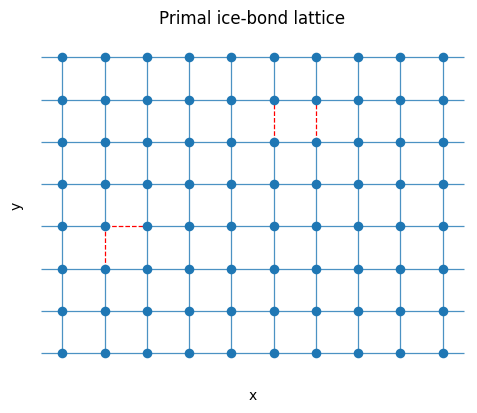

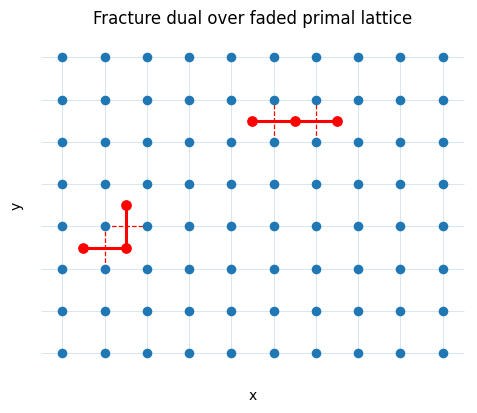

In [9]:
# Demo
lat = build_square_lattice_periodic_x(nx_nodes=10, ny_nodes=8, periodic_x=True, a=1.0)
break_edges(lat, [((1, 2), (1, 3)), ((1, 3), (2, 3)), ((5, 5), (5, 6)), ((6, 5), (6, 6))])
# band_cut_edges(lat, j_cut=3)
fig, ax = plot_primal_lattice(
    lat,
    show_nodes=True,
    title="Primal ice-bond lattice"
)
plt.show()

F = build_fracture_dual_graph(lat)

plot_fracture_overlay(lat, F, title="Fracture dual over faded primal lattice")
plt.show()




# Module 5 — Frontier Extraction (Dual BFS → Primal Candidate Bonds)

This module generates a **candidate list of intact primal bonds** that are eligible to break next.

We compute the frontier by expanding on the **dual graph** in layers (BFS-style):

1. Choose a set of **seed dual nodes** from the current fracture:
   - default: **all active dual nodes** (nodes incident to at least one fracture dual edge)
   - optional: **dual tips only** (degree 1 nodes in the fracture dual)
   - optional: **turning points** (nodes where the local crack direction changes — placeholder for now)

2. Expand outward for `steps` layers on the **full dual graph**.

3. For each traversed dual step `(f → g)`, add the crossed **primal bond** (stored as `primal_edge` on the dual edge) to the candidate set.

4. **Exclude broken** primal bonds from candidates.

## `steps` (lookahead depth)
`steps` controls how far the algorithm is allowed to look ahead in the dual:
- `steps = 1` considers bonds crossed by dual moves adjacent to the chosen seeds
- `steps > 1` includes bonds reachable by multiple dual moves, enabling deeper batch selections

## Outer faces
We allow outer faces (e.g. `TOP_OUT`, `BOTTOM_OUT`) to be *included* so boundary-adjacent candidates can appear,
but we **do not expand further** from outer faces (they are absorbing boundary nodes in the BFS).

## Notes / future extensions
- The default seeding uses **all active dual nodes**, which can include candidates along the crack body.
  You can tighten this by switching to tips or turning points (toggle below).
- "Turning points" is left as a stub until we finalize the precise definition on the dual.


In [10]:
from collections import deque
from typing import Set

# --- Frontier seed selection helpers ---

def _fracture_active_dual_nodes(F_dual):
    """Nodes incident to at least one active fracture edge."""
    return {n for n in F_dual.nodes() if F_dual.degree(n) > 0}

def _fracture_tip_dual_nodes(F_dual):
    """Dual tips = degree-1 nodes in fracture dual."""
    return {n for n in F_dual.nodes() if F_dual.degree(n) == 1}

def _fracture_turning_dual_nodes(F_dual, lattice):
    """
    Placeholder: turning points in the fracture dual.
    Not implemented yet because the exact definition depends on how you want to interpret
    'direction change' on the dual embedding.

    Current behaviour: returns tips as a conservative proxy (so it does something sensible).
    TODO: Replace with a true turning-point detector:
      - infer local direction of each incident fracture dual edge (via primal_edge_phi or dual geometry)
      - mark nodes where incident directions are not collinear
    """
    return _fracture_tip_dual_nodes(F_dual)

def _is_outer_face(face) -> bool:
    return face == ("outer", "top") or face == ("outer", "bottom")


# --- Core frontier function ---

def crack_frontier_edges(
    lattice,
    steps: int = 1,
    seed_mode: str = "active",   # "active" (default), "tips", "turning"
    return_debug: bool = True,
):
    """
    Dual-BFS frontier candidate generator.

    Parameters
    ----------
    steps:
        Number of BFS layers to expand on the full dual graph (>=1).
    seed_mode:
        "active"  -> all active dual nodes (default)  [NOTE: can include along-crack candidates]
        "tips"    -> dual tips only (degree 1 nodes in fracture dual)
        "turning" -> turning points (currently stubbed; returns tips as proxy)
    return_debug:
        If True, returns a dict with debug info and sets.
        If False, returns only the sorted list of candidate primal edges.

    Returns
    -------
    frontier_edges: List[Tuple[node,node]] OR dict
        Candidate intact primal edges (canonical) crossed by traversed dual steps.
    """
    if steps < 1:
        raise ValueError("steps must be >= 1")

    # Full dual graph: contains all dual edges with attribute "primal_edge"
    D = build_dual_graph(lattice)

    # Fracture dual graph: active dual edges only (broken bonds)
    F = build_fracture_dual_graph(lattice)

    active_nodes = _fracture_active_dual_nodes(F)
    if not active_nodes:
        out = {
            "frontier_edges": [],
            "seed_nodes": set(),
            "seed_mode": seed_mode,
            "steps": steps,
            "visited_by_layer": [],
            "mode": "empty_fracture",
        }
        return out if return_debug else []

    # Choose seeds (toggle)
    seed_mode = seed_mode.lower().strip()
    if seed_mode == "active":
        seed_nodes = set(active_nodes)
        # NOTE: Decision: seeds are all active nodes by default.
        # You may later tighten to tips or turning points for more "growth-like" candidates.
    elif seed_mode == "tips":
        seed_nodes = _fracture_tip_dual_nodes(F)
        if not seed_nodes:
            seed_nodes = set(active_nodes)  # fallback for loops/bands
    elif seed_mode == "turning":
        seed_nodes = _fracture_turning_dual_nodes(F, lattice)
        if not seed_nodes:
            seed_nodes = set(active_nodes)
    else:
        raise ValueError(f"Unknown seed_mode='{seed_mode}'. Use 'active', 'tips', or 'turning'.")

    # BFS layering on dual nodes
    seen: Set[Any] = set(seed_nodes)
    current_layer: Set[Any] = set(seed_nodes)
    visited_by_layer: List[Set[Any]] = [set(current_layer)]

    candidate_primal: Set[Tuple[Any, Any]] = set()

    for depth in range(1, steps + 1):
        next_layer: Set[Any] = set()

        for f in current_layer:
            for g in D.neighbors(f):
                # Add crossed primal edge as candidate
                attr = D[f][g]
                pe = attr.get("primal_edge", None)
                if pe is not None:
                    u, v = pe
                    # Exclude broken bonds
                    if lattice.G[u][v].get("broken", False):
                        pass
                    else:
                        candidate_primal.add(canonical_edge(u, v))

                # Discover next node
                if g in seen:
                    continue
                seen.add(g)

                # Allow outer faces to be included but DO NOT expand from them
                if _is_outer_face(g):
                    continue

                next_layer.add(g)

        if not next_layer:
            break

        current_layer = next_layer
        visited_by_layer.append(set(current_layer))

    frontier_list = sorted(candidate_primal)

    out = {
        "frontier_edges": frontier_list,
        "seed_nodes": seed_nodes,
        "seed_mode": seed_mode,
        "steps": steps,
        "visited_by_layer": visited_by_layer,
        "mode": "dual_bfs",
    }
    return out if return_debug else frontier_list


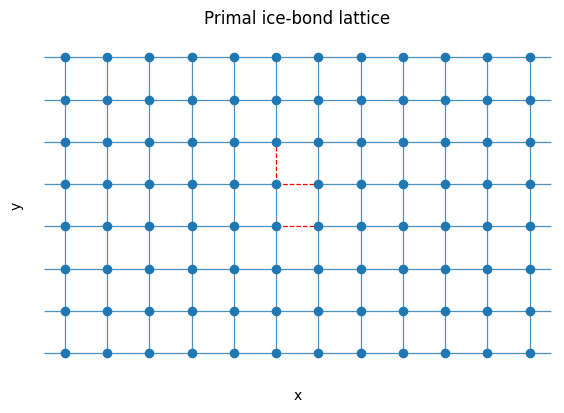

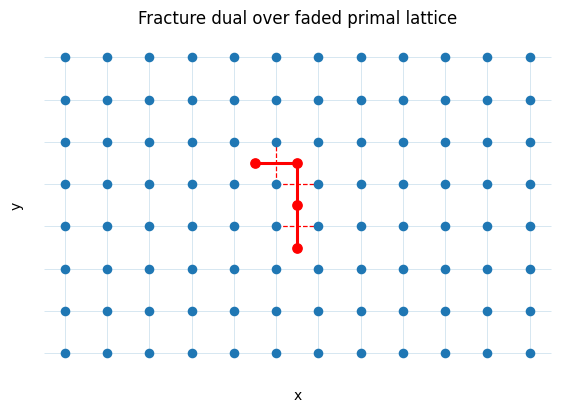

seed_mode: active | steps: 1 | candidates: 10


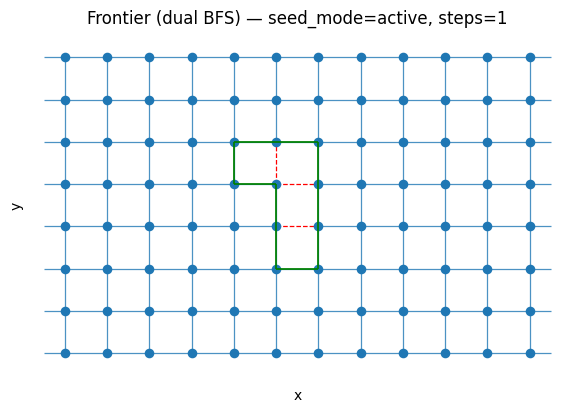

seed_mode: active | steps: 2 | candidates: 32


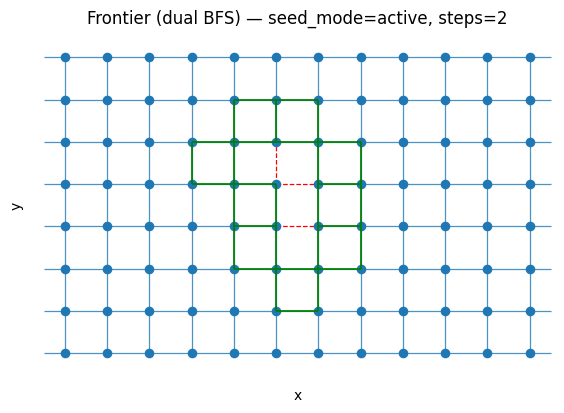

seed_mode: active | steps: 3 | candidates: 62


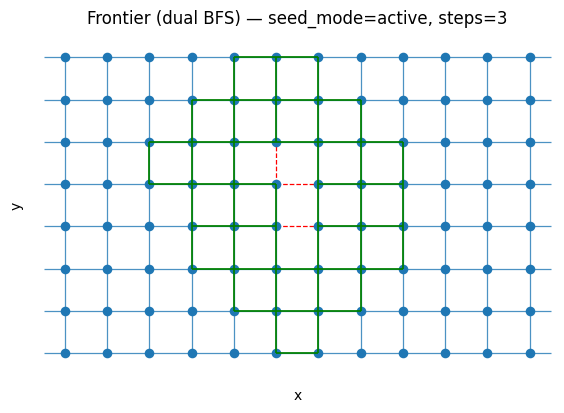

In [11]:
# Helper: overlay frontier candidates on primal lattice (green edges)
def plot_primal_with_frontier(lattice, frontier_edges, title="Frontier candidates"):
    fig, ax = plot_primal_lattice(lattice, show_nodes=True, title=None)

    segments = []
    for (u, v) in frontier_edges:
        segments.extend(_edge_segments_primal(lattice, u, v))

    if segments:
        lc_frontier = LineCollection(
            segments,
            linewidths=1.4,
            linestyles="solid",
            colors="green",
            alpha=0.9,
            zorder=4
        )
        ax.add_collection(lc_frontier)

    if title:
        ax.set_title(title)
    return fig, ax


# Demo
lat = build_square_lattice_periodic_x(nx_nodes=12, ny_nodes=8, periodic_x=True, a=1.0)
# Example: short crack seed
seed_edges = [((6, 3), (5, 3)), ((6, 4), (5, 4)),((5, 4), (5, 5))]
break_edges(lat, seed_edges)

# band_cut_edges(lat, j_cut=3)
fig, ax = plot_primal_lattice(
    lat,
    show_nodes=True,
    title="Primal ice-bond lattice"
)
plt.show()

F = build_fracture_dual_graph(lat)

plot_fracture_overlay(lat, F, title="Fracture dual over faded primal lattice")
plt.show()

out = crack_frontier_edges(lat, steps=1, seed_mode="active", return_debug=True)
print("seed_mode:", out["seed_mode"], "| steps:", out["steps"], "| candidates:", len(out["frontier_edges"]))
plot_primal_with_frontier(lat, out["frontier_edges"], title="Frontier (dual BFS) — seed_mode=active, steps=1")
plt.show()

out2 = crack_frontier_edges(lat, steps=2, seed_mode="active", return_debug=True)
print("seed_mode:", out2["seed_mode"], "| steps:", out2["steps"], "| candidates:", len(out2["frontier_edges"]))
plot_primal_with_frontier(lat, out2["frontier_edges"], title="Frontier (dual BFS) — seed_mode=active, steps=2")
plt.show()
out3 = crack_frontier_edges(lat, steps=3, seed_mode="active", return_debug=True)
print("seed_mode:", out3["seed_mode"], "| steps:", out3["steps"], "| candidates:", len(out3["frontier_edges"]))
plot_primal_with_frontier(lat, out3["frontier_edges"], title="Frontier (dual BFS) — seed_mode=active, steps=3")
plt.show()


# Module 6 — Mechanics (with shear) & Energy-Based Scoring

This module replaces the axial-only spring proxy with a **square-lattice bond model that
includes shear** while preserving the **square primal lattice** for fracture/QAOA mapping.

## Model
Each intact primal bond (edge) contributes a 2×2 stiffness of the form:

\[
K_\text{bond} = k_n\, n n^T + k_t\, t t^T
\]

where:
- \(n\) is the unit vector along the bond,
- \(t\) is the in-plane perpendicular vector.

This introduces shear resistance and improves load transmission compared to axial-only springs.

## Crack representation
Cracks are represented as **broken bonds** (removed edges). Mechanically, this is equivalent
to removing the interface coupling across that bond (traction-free interface in a penalty sense).

> Note: This does not create a mathematically exact displacement discontinuity (that would
> require node duplication / discontinuous kinematics). A future Recho/Hamiltonian upgrade
> improves the *energy functional* (anisotropy, interfaces) but does not by itself guarantee
> true crack-face displacement jumps without a discontinuous formulation.

## Plane stress
We treat the problem as 2D (plane stress assumption): all displacements and forces are in-plane.
This is appropriate for thin-sheet approximations and keeps the mechanics purely 2D.

## Outputs
We return:
- nodal displacement solution
- total elastic energy
- per-edge normal/shear extensions and forces
- per-edge elastic energy (used for scoring)



auto scale = 872, max |u| = 0.00161


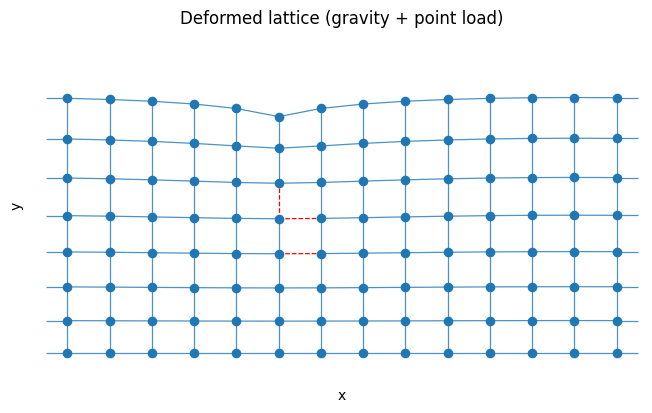

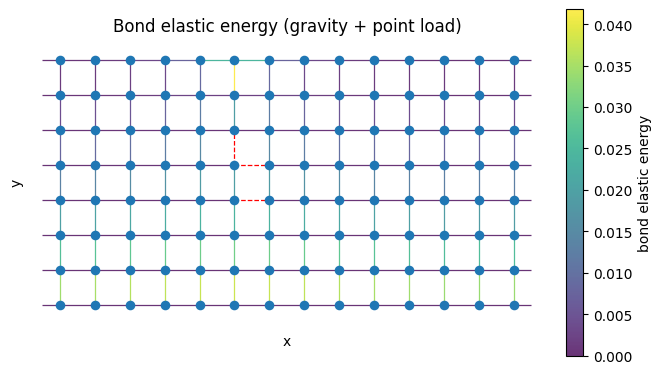

In [16]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def _node_dof_index(node, dof, node_index):
    # dof: 0=ux, 1=uy
    return 2 * node_index[node] + dof

def _bond_unit_vectors(lattice, u, v):
    x1, y1 = lattice.G.nodes[u]["x"], lattice.G.nodes[u]["y"]
    x2, y2 = lattice.G.nodes[v]["x"], lattice.G.nodes[v]["y"]
    dx, dy = x2 - x1, y2 - y1
    L = np.hypot(dx, dy)
    n = np.array([dx, dy]) / L                # along-bond
    t = np.array([-n[1], n[0]])               # in-plane perpendicular
    return L, n, t

def _canonical_edge(u, v):
    return (u, v) if u <= v else (v, u)


def solve_mechanics_shear_bonds(
    lattice,
    kn=1e4,                    # normal stiffness per bond
    kt=1e4,                    # shear stiffness per bond (set ~ kn for "rigid-ish")
    g=1.0,
    m_node=1.0,
    uniform_load=(0.0, 0.0),   # (Fx,Fy) added to every node
    point_load=None,           # (node, Fx, Fy)
    pin_ux_node=(0, 0),
    return_debug=True,
):
    """
    Solve K u = f using a square-lattice bond model with shear.

    - Each intact edge contributes: Kbond = kn * (n n^T) + kt * (t t^T)
    - Cracks: broken bonds are removed edges -> they contribute nothing
    - Loads: gravity + optional uniform + optional point
    - BC: bottom row uy=0; pin one ux=0 to remove rigid horizontal translation
    """

    nodes = list(lattice.G.nodes())
    N = len(nodes)
    node_index = {n: i for i, n in enumerate(nodes)}
    ndof = 2 * N

    K = lil_matrix((ndof, ndof), dtype=float)
    f = np.zeros(ndof, dtype=float)

    # --- Assemble stiffness from intact bonds (edges present) ---
    for u, v in lattice.G.edges():
        L, n, t = _bond_unit_vectors(lattice, u, v)

        Kbond = kn * np.outer(n, n) + kt * np.outer(t, t)

        for a in range(2):
            for b in range(2):
                iu_a = _node_dof_index(u, a, node_index)
                iu_b = _node_dof_index(u, b, node_index)
                iv_a = _node_dof_index(v, a, node_index)
                iv_b = _node_dof_index(v, b, node_index)

                K[iu_a, iu_b] += Kbond[a, b]
                K[iv_a, iv_b] += Kbond[a, b]
                K[iu_a, iv_b] -= Kbond[a, b]
                K[iv_a, iu_b] -= Kbond[a, b]

    # --- Loads ---
    for n in nodes:
        fx_add, fy_add = uniform_load
        f[_node_dof_index(n, 0, node_index)] += fx_add
        f[_node_dof_index(n, 1, node_index)] += fy_add
        f[_node_dof_index(n, 1, node_index)] -= m_node * g

    if point_load is not None:
        n, Fx, Fy = point_load
        f[_node_dof_index(n, 0, node_index)] += Fx
        f[_node_dof_index(n, 1, node_index)] += Fy

    # --- Constraints ---
    constrained = {}

    # bottom row uy = 0
    for (i, j) in nodes:
        if j == 0:
            constrained[_node_dof_index((i, j), 1, node_index)] = 0.0

    # pin one ux = 0 to remove rigid drift
    constrained[_node_dof_index(pin_ux_node, 0, node_index)] = 0.0

    # elimination
    fixed = set(constrained.keys())
    free_dofs = np.array([d for d in range(ndof) if d not in fixed], dtype=int)

    Kff = K[free_dofs, :][:, free_dofs].tocsr()
    ff = f[free_dofs]

    uf = spsolve(Kff, ff)

    uvec = np.zeros(ndof, dtype=float)
    uvec[free_dofs] = uf
    for d, val in constrained.items():
        uvec[d] = val

    # total energy
    Kcsr = K.tocsr()
    U = 0.5 * uvec @ (Kcsr @ uvec)

    # per-edge quantities (normal/shear extensions, forces, energies)
    edge_dn = {}
    edge_dt = {}
    edge_Fn = {}
    edge_Ft = {}
    edge_energy = {}

    for u, v in lattice.G.edges():
        _, n, t = _bond_unit_vectors(lattice, u, v)

        du = np.array([
            uvec[_node_dof_index(v, 0, node_index)] - uvec[_node_dof_index(u, 0, node_index)],
            uvec[_node_dof_index(v, 1, node_index)] - uvec[_node_dof_index(u, 1, node_index)],
        ])

        dn = float(np.dot(du, n))
        dt = float(np.dot(du, t))

        Fn = kn * dn
        Ft = kt * dt

        Ee = 0.5 * (kn * dn**2 + kt * dt**2)

        e = _canonical_edge(u, v)
        edge_dn[e] = dn
        edge_dt[e] = dt
        edge_Fn[e] = abs(Fn)
        edge_Ft[e] = abs(Ft)
        edge_energy[e] = Ee

    out = {
        "u": uvec,
        "U": float(U),
        "node_index": node_index,
        "edge_dn": edge_dn,
        "edge_dt": edge_dt,
        "edge_Fn": edge_Fn,
        "edge_Ft": edge_Ft,
        "edge_energy": edge_energy,
        "params": {"kn": kn, "kt": kt, "g": g, "m_node": m_node},
    }
    return out if return_debug else (uvec, U)


def score_edges_local_energy(solution, candidate_edges):
    """
    Energy-based local proxy: use per-bond elastic energy.

    This is the discrete energy analogue of Griffith-style reasoning:
    bonds storing more elastic energy are more likely to break.
    """
    scores = {}
    for e in candidate_edges:
        scores[e] = solution["edge_energy"].get(e, 0.0)
    return scores


def score_edges_recho_placeholder(solution, candidate_edges):
    """
    Placeholder for Recho/Hamiltonian-based scoring.

    Upgrading from the current (kn,kt) bond energy model to a Hamiltonian formalism is useful for:
    - anisotropy (orientation-dependent response)
    - interfaces / heterogeneous materials
    - more rigorous fracture-driving energy measures

    Note: A Hamiltonian upgrade improves the energy functional but does not *by itself* ensure true
    displacement jumps across cracks unless the kinematics also allow discontinuities
    (e.g., node duplication / DG-style formulation).
    """
    raise NotImplementedError("Recho/Hamiltonian scoring not implemented yet.")


def make_point_load(lattice, node=None, Fx=0.0, Fy=-10.0):
    if node is None:
        node = (lattice.nx_nodes // 2, lattice.ny_nodes - 1)
    if node not in lattice.G:
        raise ValueError(f"Point-load node {node} not in lattice.")
    return (node, float(Fx), float(Fy))


def plot_deformed_lattice_auto(lattice, solution, scale=None, target_frac=0.15, title="Deformed lattice"):
    # backup
    orig = {n: (lattice.G.nodes[n]["x"], lattice.G.nodes[n]["y"]) for n in lattice.G.nodes()}
    u = solution["u"]
    idx = solution["node_index"]

    disp = []
    for n, k in idx.items():
        disp.append(np.hypot(u[2*k], u[2*k+1]))
    max_disp = float(np.max(disp)) if disp else 0.0

    if scale is None:
        H = (lattice.ny_nodes - 1) * lattice.a
        scale = (target_frac * H) / max_disp if max_disp > 1e-12 else 1.0

    for n, k in idx.items():
        lattice.G.nodes[n]["x"] = orig[n][0] + scale * u[2*k]
        lattice.G.nodes[n]["y"] = orig[n][1] + scale * u[2*k+1]

    fig, ax = plot_primal_lattice(lattice, show_nodes=True, title=title)

    # restore
    for n in lattice.G.nodes():
        lattice.G.nodes[n]["x"], lattice.G.nodes[n]["y"] = orig[n]

    return fig, ax, scale, max_disp


def plot_lattice_energy(lattice, solution, title="Bond elastic energy"):
    fig, ax = plot_primal_lattice(
        lattice,
        edge_scalar=solution["edge_energy"],
        scalar_label="bond elastic energy",
        show_nodes=True,
        title=title,
    )
    return fig, ax


# --- Demo run ---
lat = build_square_lattice_periodic_x(nx_nodes=14, ny_nodes=8, periodic_x=True, a=1.0)

# optional crack
seed_edges = [((6, 3), (5, 3)), ((6, 4), (5, 4)),((5, 4), (5, 5))]
break_edges(lat, edges=seed_edges)


pl = make_point_load(lat, node=(5, 7), Fy=-700.0)  # downward point load at top center

sol = solve_mechanics_shear_bonds(
    lat,
    kn=1e6,
    kt=1e6,
    g=1.0,          # gravity ON
    m_node=1.0,
    uniform_load=(0.0, -30.0),
    point_load=pl,  # plus point load
    pin_ux_node=(0, 0),
)

fig, ax, used_scale, max_disp = plot_deformed_lattice_auto(
    lat, sol, scale=None, target_frac=0.2,
    title="Deformed lattice (gravity + point load)"
)
print(f"auto scale = {used_scale:.3g}, max |u| = {max_disp:.3g}")
plt.show()

plot_lattice_energy(lat, sol, title="Bond elastic energy (gravity + point load)")
plt.show()


# Module 7 — QAOA batch selection of k new breaks (score + connectivity + cardinality)

This is the **quantum core** of the pipeline.

We take a set of frontier candidate bonds and choose **exactly k** to break in the next “event”
(batch propagation), balancing:

1) **High fracture score** (from mechanics / energy proxy)  
2) **Connected propagation** (prefer sets of breaks that connect to each other)  
3) **Cardinality** (break exactly k bonds in this step)

## What “cardinality” means here
We introduce one binary variable per candidate bond:
- \(z_i = 1\) means “break candidate bond i”
- \(z_i = 0\) means “don’t break it”

**Cardinality constraint** = “how many bonds break this step”:
\[
\sum_i z_i = k
\]
This is enforced with a penalty term.

## Objective (conceptual)
We **maximize**:
\[
\sum_i s_i z_i
\;+\;
\beta \sum_{(i,j)\in \mathcal{A}} w_{ij} z_i z_j
\;-\;
A\left(\sum_i z_i - k\right)^2
\]
- \(s_i\): mechanics-derived score (energy proxy) for breaking bond i
- adjacency set \(\mathcal{A}\): pairs of candidate bonds that “touch” (share a lattice node)
- \(w_{ij}\): (default 1) connectivity weight if i and j are adjacent
- \(\beta\): connectivity strength
- \(A\): cardinality penalty strength (large)

We run QAOA on the equivalent **Ising Hamiltonian** and extract the best bitstring.

## Notes
- If $k=1$, the problem collapses to a greedy argmax; the QAOA is not meaningfully combinatorial.
- For $k\ge 2$, with adjacency couplings, the selection becomes genuinely combinatorial.


In [17]:
from scipy.optimize import minimize
from typing import Sequence

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler


# Runtime imports (used both for simulator and hardware)
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

# QiskitRuntimeService.save_account(channel="ibm_quantum", token="", overwrite=True)

# service = QiskitRuntimeService(channel="ibm_quantum")
# print("Service ready.")

In [18]:
# Module 7 — QAOA selector 
# IBM tutorial reference:
# https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm

# Pick a backend with at least n qubits (n = number of candidates after truncation)
# You can also hardcode a backend name if you prefer.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=30)
# print("Using backend:", backend.name)
def _build_cost_hamiltonian(
    candidate_edges,
    edge_scores,
    k_new,
    beta,
    gamma_isolation=0.0, 
):
    """
    H = - sum_i s_i x_i
        - beta * sum_(i,j adjacent) x_i x_j
        + A (sum_i x_i - k)^2
        + gamma * sum_i x_i(1 - sum_{j in N(i)} x_j)   [optional, k_new>=2]
    """
    n = len(candidate_edges)
    idx = {e: i for i, e in enumerate(candidate_edges)}

    # adjacency: share a node (or swap to your orientation-aware adjacency here)
    adj_pairs = []
    for e1, e2 in combinations(candidate_edges, 2):
        if set(e1) & set(e2):
            adj_pairs.append((idx[e1], idx[e2]))

    # penalty scale for exact-k
    score_vals = np.array([edge_scores[e] for e in candidate_edges], dtype=float)
    A = 5.0 * max(1.0, float(np.max(np.abs(score_vals))))

    h = np.zeros(n, dtype=float)
    J = {}

    # --- score term: -s_i x_i  => + (s_i/2) Z_i  (up to constant)
    for e, i in idx.items():
        h[i] += edge_scores[e] / 2.0

    # --- adjacency reward: -beta * x_i x_j
    for i, j in adj_pairs:
        h[i] += beta / 4.0
        h[j] += beta / 4.0
        key = (i, j) if i < j else (j, i)
        J[key] = J.get(key, 0.0) - beta / 4.0

    # --- isolation penalty (only meaningful if selecting >=2 edges)
    if k_new >= 2 and gamma_isolation > 0.0:
        # Build neighbor sets from adj_pairs
        N = [set() for _ in range(n)]
        for i, j in adj_pairs:
            N[i].add(j)
            N[j].add(i)

        # penalty: gamma * sum_i x_i  - gamma * sum_{i} sum_{j in N(i)} x_i x_j
        # Linear: +gamma * x_i => in Ising contributes -(gamma/2) Z_i (dropping const)
        # Quadratic: -gamma * x_i x_j => contributes similar to adjacency reward
        # We'll implement directly in Ising coefficient form by reusing x->Z mapping effects:
        # x_i term adds: -(gamma/2) * Z_i  (since x_i=(1-Z_i)/2 => +gamma*x_i => const - (gamma/2)Z_i)
        h += -(gamma_isolation / 2.0)

        # For each adjacent pair, add extra reward: -gamma * x_i x_j
        # which in Ising contributes: +gamma/4 on Z_i and Z_j, and -gamma/4 on Z_i Z_j
        for i, j in adj_pairs:
            h[i] += gamma_isolation / 4.0
            h[j] += gamma_isolation / 4.0
            key = (i, j) if i < j else (j, i)
            J[key] = J.get(key, 0.0) - gamma_isolation / 4.0

    # --- exact-k penalty: A (sum x - k)^2
    h += A * (k_new - n / 2.0)
    for i in range(n):
        for j in range(i + 1, n):
            J[(i, j)] = J.get((i, j), 0.0) + A / 2.0

    # Build SparsePauliOp
    paulis = []
    for i in range(n):
        if abs(h[i]) > 1e-9:
            paulis.append(("Z", [i], float(h[i])))
    for (i, j), v in J.items():
        if abs(v) > 1e-9:
            paulis.append(("ZZ", [i, j], float(v)))

    return SparsePauliOp.from_sparse_list(paulis, num_qubits=n)

def _select_greedy(candidate_edges, edge_scores, k_new):
    ranked = sorted(
        candidate_edges,
        key=lambda e: edge_scores[e],
        reverse=True
    )
    return ranked[:k_new], {"mode": "greedy"}

def _run_qaoa(
    cost_hamiltonian,
    backend,
    reps,
    shots,
    estimator,
    sampler,
):
    circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
    circuit.measure_all()

    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    circuit = pm.run(circuit)

    def cost_fn(params):
        isa_h = cost_hamiltonian.apply_layout(circuit.layout)
        job = estimator.run([(circuit, isa_h, params)])
        return float(job.result()[0].data.evs)

    init = np.array([np.pi / 2] * reps + [np.pi] * reps)
    opt = minimize(cost_fn, init, method="COBYLA", tol=1e-2)

    bound = circuit.assign_parameters(opt.x)
    job = sampler.run([(bound,)], shots=shots)
    counts = job.result()[0].data.meas.get_int_counts()

    return counts, opt

def _select_qaoa_aer(
    candidate_edges,
    edge_scores,
    k_new,
    beta,
    reps,
    shots,
):
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import EstimatorV2, SamplerV2

    backend = AerSimulator()
    H = _build_cost_hamiltonian(candidate_edges, edge_scores, k_new, beta)

    estimator = EstimatorV2()
    sampler = SamplerV2()

    counts, opt = _run_qaoa(H, backend, reps, shots, estimator, sampler)

    best = max(counts, key=counts.get)
    bitstring = format(best, f"0{len(candidate_edges)}b")

    sel = [candidate_edges[i] for i, b in enumerate(bitstring) if b == "1"]
    sel = sorted(sel, key=lambda e: edge_scores[e], reverse=True)[:k_new]

    return sel, {"mode": "aer", "bitstring": bitstring, "counts": counts}

def _select_qaoa_ibm(
    candidate_edges,
    edge_scores,
    k_new,
    beta,
    reps,
    shots,
    ibm_service,
):
    from qiskit_ibm_runtime import Session, EstimatorV2, SamplerV2

    H = _build_cost_hamiltonian(candidate_edges, edge_scores, k_new, beta)

    backend = ibm_service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=len(candidate_edges),
    )

    with Session(service=ibm_service, backend=backend) as session:
        estimator = EstimatorV2(mode=session)
        sampler = SamplerV2(mode=session)

        counts, opt = _run_qaoa(H, backend, reps, shots, estimator, sampler)

    best = max(counts, key=counts.get)
    bitstring = format(best, f"0{len(candidate_edges)}b")

    sel = [candidate_edges[i] for i, b in enumerate(bitstring) if b == "1"]
    sel = sorted(sel, key=lambda e: edge_scores[e], reverse=True)[:k_new]

    return sel, {
        "mode": "ibm",
        "backend": backend.name,
        "bitstring": bitstring,
        "counts": counts,
    }

def select_bonds_module7(
    candidate_edges,
    edge_scores,
    k_new,
    *,
    mode="greedy",
    beta=1.0,
    reps=2,
    max_candidates=20,
    shots=2048,
    ibm_service=None,
):
    if len(candidate_edges) > max_candidates:
        candidate_edges = sorted(
            candidate_edges,
            key=lambda e: edge_scores[e],
            reverse=True
        )[:max_candidates]

    if mode == "greedy":
        return _select_greedy(candidate_edges, edge_scores, k_new)

    if mode == "aer":
        return _select_qaoa_aer(
            candidate_edges, edge_scores, k_new, beta, reps, shots
        )

    if mode == "ibm":
        if ibm_service is None:
            raise ValueError("IBM service required for mode='ibm'")
        return _select_qaoa_ibm(
            candidate_edges, edge_scores, k_new, beta, reps, shots, ibm_service
        )

    raise ValueError(f"Unknown mode: {mode}")


In [19]:
from itertools import combinations
# =========================
# MODULE 8 — Fracture evolution loop (one user-facing function)
# =========================

# ------------------------------------------------------------
# Utilities (purely classical, physics-agnostic)
# ------------------------------------------------------------

def compute_top_bottom_mincut(lat):
    """
    Top–bottom min-cut on primal graph.
    Broken edges assumed to have capacity 0.
    """
    G = lat.G
    ny = lat.ny_nodes

    top_nodes = [(i, ny - 1) for i in range(lat.nx_nodes)]
    bottom_nodes = [(i, 0) for i in range(lat.nx_nodes)]

    D = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        cap = float(d.get("capacity", 1.0))
        D.add_edge(u, v, capacity=cap)
        D.add_edge(v, u, capacity=cap)

    s, t = "__TOP__", "__BOTTOM__"
    D.add_node(s)
    D.add_node(t)

    INF = 1e9
    for n in top_nodes:
        D.add_edge(s, n, capacity=INF)
    for n in bottom_nodes:
        D.add_edge(n, t, capacity=INF)

    cut_value, (S, T) = nx.minimum_cut(D, s, t, capacity="capacity")

    cut_edges = []
    for u, v in G.edges():
        if (u in S and v in T) or (v in S and u in T):
            cut_edges.append(canonical_edge(u, v))

    return cut_value, cut_edges


def report_fracture_connectivity(lat):
    """
    Report connected components of broken bonds (primal)
    and dual fracture graph.
    """
    H = nx.Graph()
    for u, v, d in lat.G.edges(data=True):
        if d.get("broken", False):
            H.add_edge(u, v)

    if H.number_of_edges() == 0:
        print("[Connectivity] no broken bonds yet")
    else:
        comps = list(nx.connected_components(H))
        sizes = sorted((len(c) for c in comps), reverse=True)
        print(f"[Connectivity] primal crack components: {len(comps)} | sizes={sizes}")

    F = build_fracture_dual_graph(lat)
    if F.number_of_edges() == 0:
        print("[Connectivity] dual fracture empty")
    else:
        compsF = list(nx.connected_components(F))
        sizesF = sorted((len(c) for c in compsF), reverse=True)
        print(f"[Connectivity] dual fracture components: {len(compsF)} | sizes={sizesF}")


# ------------------------------------------------------------
# MODULE 8 — The ONLY user-facing loop
# ------------------------------------------------------------

def run_fracture_simulation(
    lat,
    *,
    seed_edges,
    k_new=2,
    max_iters=30,

    # --- Module 5 (frontier)
    frontier_steps=1,
    frontier_seed_mode="tips",

    # --- Module 6 (mechanics)
    mechanics_kwargs=None,

    # --- Module 7 (selection)
    selector_mode="greedy",     # "greedy" | "aer" | "ibm"
    beta=1.0,
    reps=2,
    shots=2048,
    max_candidates=20,
    ibm_service=None,

    # --- Termination
    mincut_eps=0.0,

    # --- Plot toggles (ALL ON BY DEFAULT)
    plot_lattice=True,
    plot_frontier=True,
    plot_energy=True,
    plot_dual=True,
    plot_mincut_preview=True,
    print_connectivity=True,

    verbose=True,
):
    """
    Clean fracture evolution loop.
    This is the ONLY function a user needs to call.
    """

    if mechanics_kwargs is None:
        mechanics_kwargs = dict(
            kn=1e5,
            kt=1e5,
            g=0.0,
            m_node=1.0,
            uniform_load=(0.0, -10.0),
            point_load=None,
            pin_ux_node=(0, 0),
            return_debug=True,
        )

    # --------------------------------------------------------
    # Initialisation
    # --------------------------------------------------------
    if verbose:
        print("=== MODULE 8: INITIALISATION ===")
        print(f"Seed crack edges: {len(seed_edges)}")

    break_edges(lat, seed_edges)

    if plot_lattice:
        plot_primal_lattice(lat, show_nodes=True, title="Initial lattice (seed crack)")

    if plot_dual:
        F0 = build_fracture_dual_graph(lat)
        plot_fracture_overlay(lat, F0, title="Initial dual fracture")

    # --- Initial min-cut preview
    cut_val0, cut_edges0 = compute_top_bottom_mincut(lat)
    if verbose:
        print(f"[MinCut preview] value={cut_val0:.6g}, edges={len(cut_edges0)}")

    if plot_mincut_preview and cut_edges0:
        lat_cut = copy.deepcopy(lat)
        break_edges(lat_cut, cut_edges0)
        plot_primal_lattice(lat_cut, show_nodes=True, title="Initial min-cut preview")

    # --------------------------------------------------------
    # Evolution loop
    # --------------------------------------------------------
    history = []

    for it in range(max_iters):
        if verbose:
            print(f"\n=== ITERATION {it} ===")

        # --- Termination check
        cut_val, _ = compute_top_bottom_mincut(lat)
        if verbose:
            print(f"[MinCut] value = {cut_val:.6g}")

        if cut_val <= mincut_eps:
            if verbose:
                print("[STOP] catastrophic failure reached")
            break

        # ----------------------------------------------------
        # Module 5 — Frontier
        # ----------------------------------------------------
        frontier_dbg = crack_frontier_edges(
            lat,
            steps=frontier_steps,
            seed_mode=frontier_seed_mode,
            return_debug=True,
        )
        candidate_edges = frontier_dbg["frontier_edges"]

        if verbose:
            print(f"[Frontier] candidates = {len(candidate_edges)}")

        if not candidate_edges:
            if verbose:
                print("[STOP] no frontier candidates")
            break

        if plot_frontier:
            plot_primal_with_frontier(
                lat, candidate_edges, title=f"Frontier (iter {it})"
            )

        # ----------------------------------------------------
        # Module 6 — Mechanics + scoring
        # ----------------------------------------------------
        solution = solve_mechanics_shear_bonds(lat, **mechanics_kwargs)

        if plot_energy:
            plot_lattice_energy(lat, solution, title=f"Bond energy (iter {it})")

        edge_scores = score_edges_local_energy(solution, candidate_edges)

        if verbose:
            top = sorted(edge_scores.items(), key=lambda kv: kv[1], reverse=True)[:6]
            print("[Scores] top candidates:")
            for e, s in top:
                print(f"  {e}  {s:.3e}")

        # ----------------------------------------------------
        # Module 7 — Selection (clean, explicit)
        # ----------------------------------------------------
        selected_edges, dbg = select_bonds_module7(
            candidate_edges,
            edge_scores,
            k_new=k_new,
            mode=selector_mode,
            beta=beta,
            reps=reps,
            shots=shots,
            max_candidates=max_candidates,
            ibm_service=ibm_service,
        )

        if verbose:
            print(f"[Select] breaking {len(selected_edges)} edges:")
            for e in selected_edges:
                print(" ", e)

        # ----------------------------------------------------
        # Apply fracture + visualise
        # ----------------------------------------------------
        break_edges(lat, selected_edges)

        if plot_lattice:
            plot_primal_lattice(
                lat, show_nodes=True, title=f"Lattice after break (iter {it})"
            )

        if plot_dual:
            F = build_fracture_dual_graph(lat)
            plot_fracture_overlay(
                lat, F, title=f"Dual fracture overlay (iter {it})"
            )

        if print_connectivity:
            report_fracture_connectivity(lat)

        history.append(
            dict(
                iteration=it,
                mincut=cut_val,
                selected_edges=selected_edges,
                selector_debug=dbg,
            )
        )

    return lat, history


In [20]:
def compute_top_bottom_mincut(lat):
    """Physics-agnostic min-cut between TOP row and BOTTOM row on the primal graph."""
    G = lat.G
    ny = lat.ny_nodes

    top_nodes = [(i, ny - 1) for i in range(lat.nx_nodes)]
    bottom_nodes = [(i, 0) for i in range(lat.nx_nodes)]

    D = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        cap = float(d.get("capacity", 1.0))
        D.add_edge(u, v, capacity=cap)
        D.add_edge(v, u, capacity=cap)

    s, t = "__TOP__", "__BOTTOM__"
    D.add_node(s)
    D.add_node(t)

    INF = 1e9
    for n in top_nodes:
        D.add_edge(s, n, capacity=INF)
    for n in bottom_nodes:
        D.add_edge(n, t, capacity=INF)

    cut_val, (S, T) = nx.minimum_cut(D, s, t, capacity="capacity")

    cut_edges = []
    for u, v in G.edges():
        if (u in S and v in T) or (v in S and u in T):
            cut_edges.append(canonical_edge(u, v))

    return float(cut_val), cut_edges

def run_fracture_simulation_clean(
    lat,
    *,
    seed_edges,
    mode="greedy",                 # "greedy" | "aer" | "ibm"
    ibm_service=None,              # required if mode="ibm"
    k_new=2,
    max_iters=10,
    max_candidates=20,
    beta=1.0,
    reps=2,
    shots=2048,
    mechanics_kwargs=None,
    frontier_steps=1,
    frontier_seed_mode="tips",
    mincut_eps=0.0,
    # plot toggles
    show_lattice=True,
    show_dual=True,
    show_frontier=True,
    show_energy=True,
    show_mincut_preview=False,
    verbose=True,
):
    """
    Clean Module 8 loop: prints each step and plots selected views each iteration.
    No extra scaffolding — this is the main driver.
    """
    if mechanics_kwargs is None:
        mechanics_kwargs = dict(
            kn=1e4,
            kt=1e4,
            g=0.0,
            m_node=1.0,
            uniform_load=(0.0, -1.0),
            point_load=None,
            pin_ux_node=(0, 0),
            return_debug=True,
        )

    if verbose:
        print("=== INIT ===")
        print(f"mode={mode}, k_new={k_new}, reps={reps}, shots={shots}, max_candidates={max_candidates}")

    # Apply seed crack
    break_edges(lat, seed_edges)

    if show_lattice:
        plot_primal_lattice(lat, show_nodes=True, title="iter=INIT | lattice (seed applied)")
    if show_dual:
        F0 = build_fracture_dual_graph(lat)
        plot_fracture_overlay(lat, F0, title="iter=INIT | dual fracture overlay")

    # Optional mincut preview
    cut0, cut_edges0 = compute_top_bottom_mincut(lat)
    if verbose:
        print(f"[MinCut INIT] value={cut0:.6g}, cut_edges={len(cut_edges0)}")
    if show_mincut_preview and cut_edges0:
        lat_cut = copy.deepcopy(lat)
        break_edges(lat_cut, cut_edges0)
        plot_primal_lattice(lat_cut, show_nodes=True, title="iter=INIT | mincut preview (edges broken)")

    history = []

    for it in range(max_iters):
        if verbose:
            print(f"\n=== ITER {it} ===")

        # Termination check
        cut_val, _ = compute_top_bottom_mincut(lat)
        if verbose:
            print(f"[MinCut] value={cut_val:.6g}")
        if cut_val <= mincut_eps:
            if verbose:
                print("[STOP] catastrophic failure (mincut <= eps)")
            break

        # Module 5: frontier
        frontier_dbg = crack_frontier_edges(
            lat,
            steps=frontier_steps,
            seed_mode=frontier_seed_mode,
            return_debug=True,
        )
        candidate_edges = frontier_dbg["frontier_edges"]
        if verbose:
            print(f"[Frontier] candidates={len(candidate_edges)} (steps={frontier_steps}, seed_mode={frontier_seed_mode})")
        if not candidate_edges:
            if verbose:
                print("[STOP] no frontier candidates")
            break

        if show_frontier:
            plot_primal_with_frontier(lat, candidate_edges, title=f"iter={it} | frontier candidates")

        # Module 6: mechanics + scoring
        solution = solve_mechanics_shear_bonds(lat, **mechanics_kwargs)
        if show_energy:
            plot_lattice_energy(lat, solution, title=f"iter={it} | bond energy")

        edge_scores = score_edges_local_energy(solution, candidate_edges)
        if verbose:
            top = sorted(edge_scores.items(), key=lambda kv: kv[1], reverse=True)[:6]
            print("[Scores] top:")
            for e, s in top:
                print(f"  {e}  {s:.3e}")

        # Module 7: selection (explicit mode)
        selected_edges, dbg = select_bonds_module7(
            candidate_edges,
            edge_scores,
            k_new=k_new,
            mode=mode,
            beta=beta,
            reps=reps,
            shots=shots,
            max_candidates=max_candidates,
            ibm_service=ibm_service,
        )
        if verbose:
            print(f"[Select] selected {len(selected_edges)} edges:")
            for e in selected_edges:
                print(" ", e)

        # Apply breaks
        break_edges(lat, selected_edges)

        # Visualise updated state
        if show_lattice:
            plot_primal_lattice(lat, show_nodes=True, title=f"iter={it} | lattice after breaks")
        if show_dual:
            F = build_fracture_dual_graph(lat)
            plot_fracture_overlay(lat, F, title=f"iter={it} | dual overlay after breaks")

        history.append(
            dict(
                iteration=it,
                mincut=cut_val,
                n_candidates=len(candidate_edges),
                selected_edges=selected_edges,
                selector_debug=dbg,
            )
        )

    return lat, history

def demo_trivial_evolution(
    *,
    mode="greedy",          # "greedy" | "aer" | "ibm"
    ibm_service=None,       # required if mode="ibm"
    iters=6,
    k_new=2,
    reps=2,
    shots=2048,
    max_candidates=20,
    beta=None,
    show_lattice=True,
    show_dual=True,
    show_frontier=True,
    show_energy=True,
    verbose=True,
    steps=1,
):
    """
    Single function you run to watch the trivial case evolve.
    """

    lat = build_square_lattice_periodic_x(
        nx_nodes=7,
        ny_nodes=6,
        periodic_x=True,
        a=1.0,
    )

    seed_edges = [((3, 2), (3, 1))]

    # Pick a reasonable default beta if not provided
    if beta is None:
        beta = 1.0  # start simple; if you see disconnected picks on QAOA, raise beta

    lat_final, hist = run_fracture_simulation_clean(
        lat,
        seed_edges=seed_edges,
        mode=mode,
        ibm_service=ibm_service,
        k_new=k_new,
        max_iters=iters,
        max_candidates=max_candidates,
        beta=beta,
        reps=reps,
        shots=shots,
        mechanics_kwargs=dict(
            kn=1e4,
            kt=1e4,
            g=0.0,
            m_node=1.0,
            uniform_load=(0.0, -1.0),
            point_load=None,
            pin_ux_node=(0, 0),
            return_debug=True,
        ),
        frontier_steps=steps,
        frontier_seed_mode="tips",
        mincut_eps=0.0,
        show_lattice=show_lattice,
        show_dual=show_dual,
        show_frontier=show_frontier,
        show_energy=show_energy,
        show_mincut_preview=False,
        verbose=verbose,
    )

    print("\n=== SUMMARY ===")
    for row in hist:
        it = row["iteration"]
        sel = row["selected_edges"]
        print(f"iter {it}: broke {len(sel)} edges -> {sel}")

    return lat_final, hist


=== INIT ===
mode=greedy, k_new=2, reps=2, shots=2048, max_candidates=20
[MinCut INIT] value=6, cut_edges=7

=== ITER 0 ===
[MinCut] value=6
[Frontier] candidates=6 (steps=1, seed_mode=tips)
[Scores] top:
  ((2, 1), (2, 2))  8.000e-04
  ((4, 1), (4, 2))  8.000e-04
  ((2, 2), (3, 2))  9.404e-34
  ((3, 2), (4, 2))  5.877e-35
  ((2, 1), (3, 1))  0.000e+00
  ((3, 1), (4, 1))  0.000e+00
[Select] selected 2 edges:
  ((2, 1), (2, 2))
  ((4, 1), (4, 2))

=== ITER 1 ===
[MinCut] value=4
[Frontier] candidates=6 (steps=1, seed_mode=tips)
[Scores] top:
  ((1, 1), (1, 2))  8.000e-04
  ((5, 1), (5, 2))  8.000e-04
  ((1, 1), (2, 1))  0.000e+00
  ((1, 2), (2, 2))  0.000e+00
  ((4, 1), (5, 1))  0.000e+00
  ((4, 2), (5, 2))  0.000e+00
[Select] selected 2 edges:
  ((1, 1), (1, 2))
  ((5, 1), (5, 2))

=== ITER 2 ===
[MinCut] value=2
[Frontier] candidates=6 (steps=1, seed_mode=tips)
[Scores] top:
  ((0, 1), (0, 2))  8.000e-04
  ((6, 1), (6, 2))  8.000e-04
  ((0, 2), (1, 2))  2.351e-34
  ((0, 1), (1, 1))  0

(IceBondLattice(G=<networkx.classes.graph.Graph object at 0x126fb1270>, nx_nodes=7, ny_nodes=6, periodic_x=True, a=1.0, _dual_cache=None),
 [{'iteration': 0,
   'mincut': 6.0,
   'n_candidates': 6,
   'selected_edges': [((2, 1), (2, 2)), ((4, 1), (4, 2))],
   'selector_debug': {'mode': 'greedy'}},
  {'iteration': 1,
   'mincut': 4.0,
   'n_candidates': 6,
   'selected_edges': [((1, 1), (1, 2)), ((5, 1), (5, 2))],
   'selector_debug': {'mode': 'greedy'}},
  {'iteration': 2,
   'mincut': 2.0,
   'n_candidates': 6,
   'selected_edges': [((0, 1), (0, 2)), ((6, 1), (6, 2))],
   'selector_debug': {'mode': 'greedy'}}])

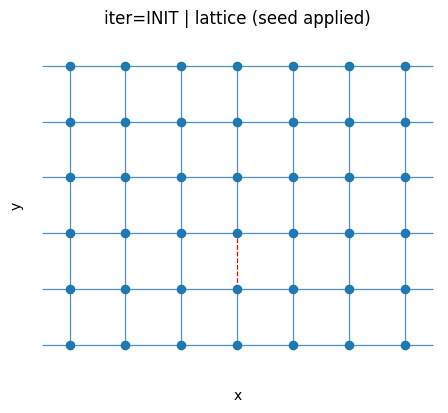

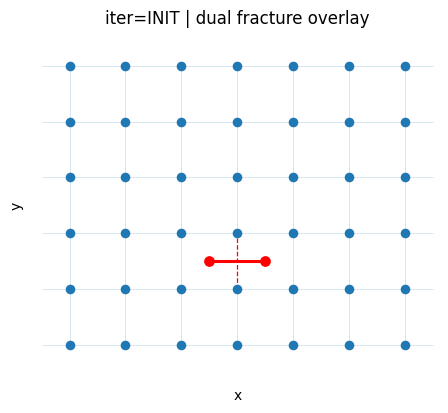

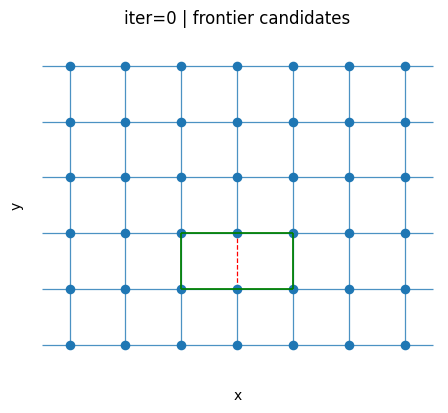

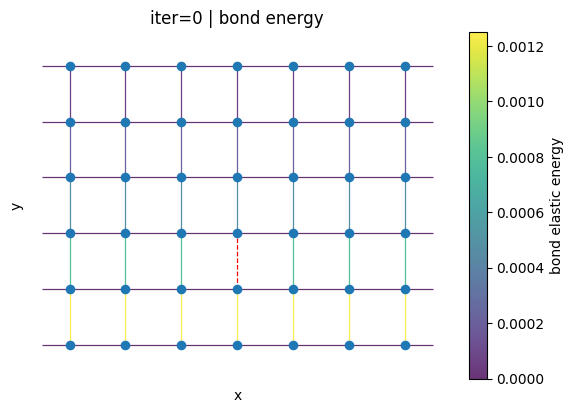

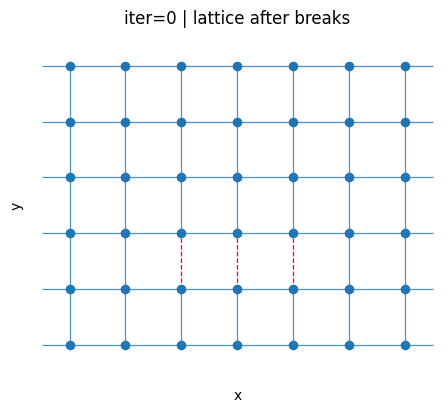

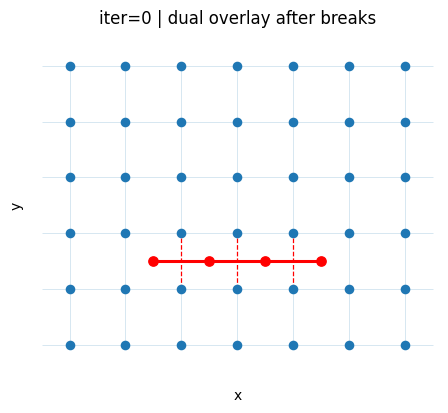

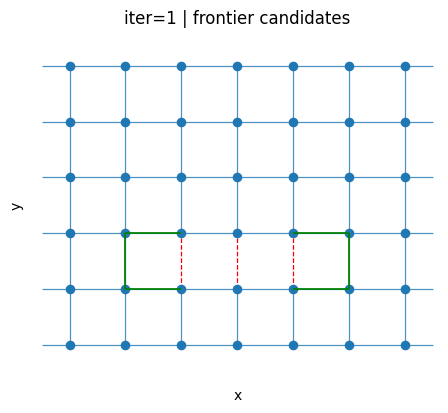

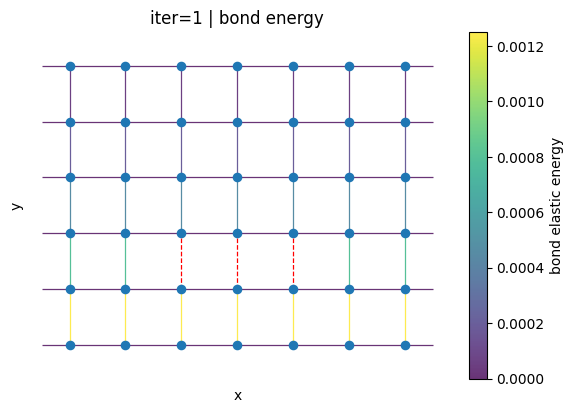

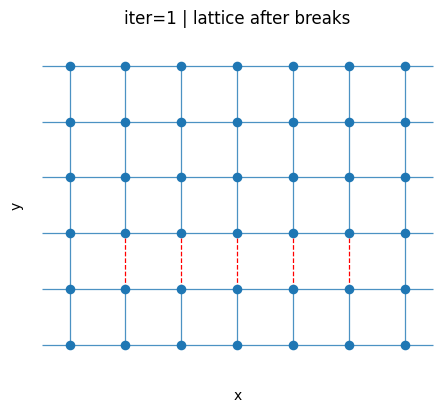

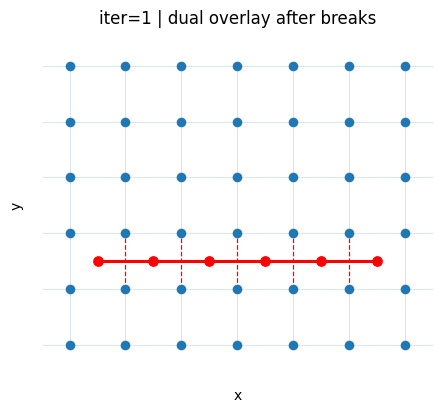

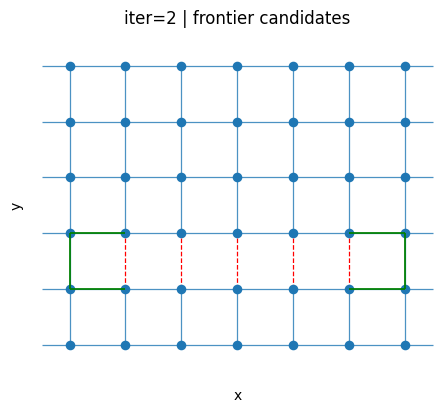

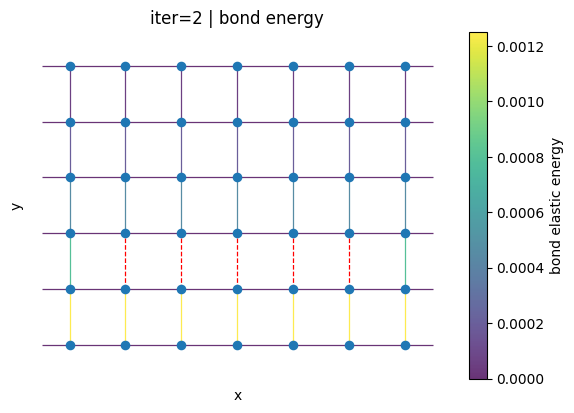

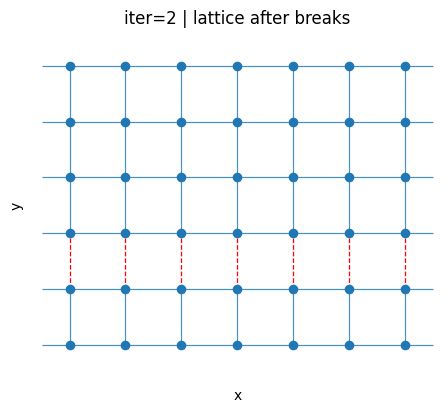

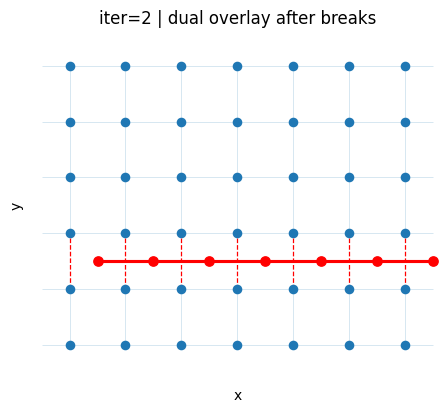

In [21]:
demo_trivial_evolution(mode="greedy", iters=5, k_new=2)

=== INIT ===
mode=aer, k_new=2, reps=2, shots=2048, max_candidates=20
[MinCut INIT] value=6, cut_edges=7

=== ITER 0 ===
[MinCut] value=6
[Frontier] candidates=6 (steps=1, seed_mode=tips)
[Scores] top:
  ((2, 1), (2, 2))  8.000e-04
  ((4, 1), (4, 2))  8.000e-04
  ((2, 2), (3, 2))  9.404e-34
  ((3, 2), (4, 2))  5.877e-35
  ((2, 1), (3, 1))  0.000e+00
  ((3, 1), (4, 1))  0.000e+00
[Select] selected 2 edges:
  ((2, 1), (3, 1))
  ((3, 1), (4, 1))

=== ITER 1 ===
[MinCut] value=6
[Frontier] candidates=5 (steps=1, seed_mode=tips)
[Scores] top:
  ((2, 0), (2, 1))  1.250e-03
  ((3, 0), (3, 1))  1.250e-03
  ((4, 0), (4, 1))  1.250e-03
  ((2, 0), (3, 0))  0.000e+00
  ((3, 0), (4, 0))  0.000e+00
[Select] selected 2 edges:
  ((4, 0), (4, 1))
  ((2, 0), (3, 0))

=== ITER 2 ===
[MinCut] value=5
[Frontier] candidates=8 (steps=1, seed_mode=tips)
[Scores] top:
  ((5, 0), (5, 1))  1.250e-03
  ((0, 0), (1, 0))  0.000e+00
  ((0, 0), (6, 0))  0.000e+00
  ((1, 0), (2, 0))  0.000e+00
  ((3, 0), (4, 0))  0.00

/var/folders/z1/kd2lj2h92lj5yvynptqvc2rw0000gn/T/ipykernel_77806/310004586.py:100: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 4.5))


(IceBondLattice(G=<networkx.classes.graph.Graph object at 0x1273d8ad0>, nx_nodes=7, ny_nodes=6, periodic_x=True, a=1.0, _dual_cache=None),
 [{'iteration': 0,
   'mincut': 6.0,
   'n_candidates': 6,
   'selected_edges': [((2, 1), (3, 1)), ((3, 1), (4, 1))],
   'selector_debug': {'mode': 'aer',
    'bitstring': '010100',
    'counts': {1: 33,
     12: 35,
     57: 28,
     6: 39,
     11: 41,
     10: 34,
     52: 30,
     16: 32,
     17: 36,
     9: 40,
     18: 30,
     44: 42,
     33: 33,
     27: 23,
     29: 32,
     38: 27,
     19: 35,
     43: 35,
     8: 43,
     63: 27,
     15: 20,
     40: 34,
     24: 25,
     50: 37,
     42: 26,
     54: 36,
     62: 29,
     34: 21,
     26: 42,
     56: 31,
     45: 32,
     13: 42,
     47: 39,
     37: 29,
     36: 36,
     28: 28,
     25: 17,
     32: 36,
     59: 39,
     22: 39,
     14: 36,
     53: 24,
     0: 28,
     31: 30,
     55: 37,
     20: 47,
     49: 23,
     3: 29,
     60: 35,
     5: 30,
     46: 32,
     23: 29,


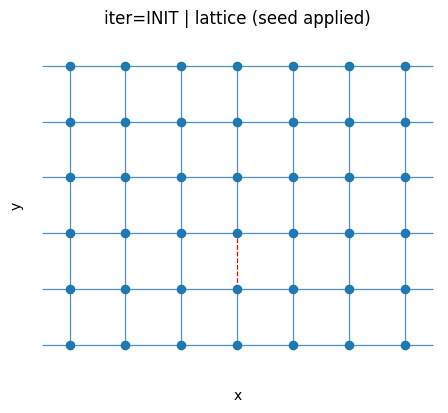

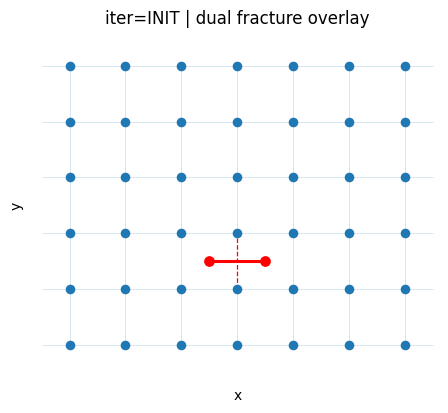

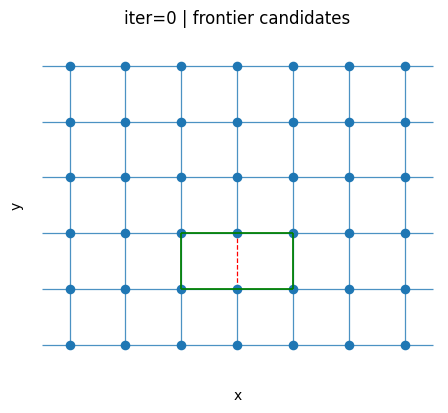

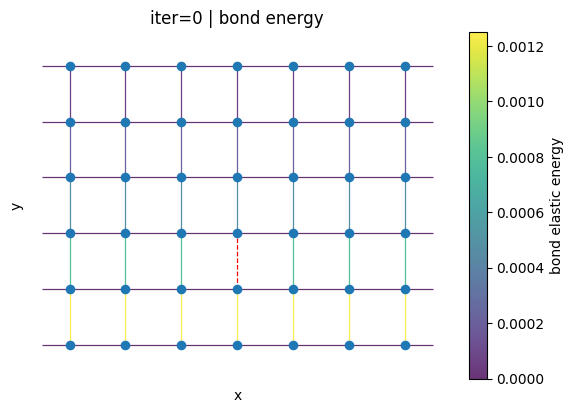

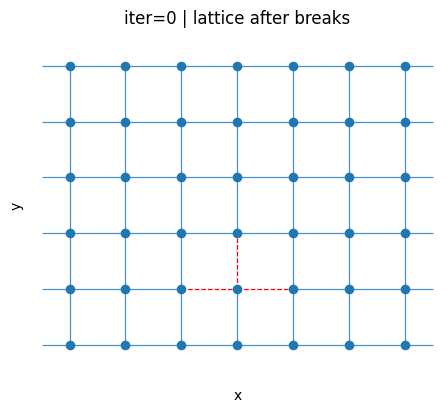

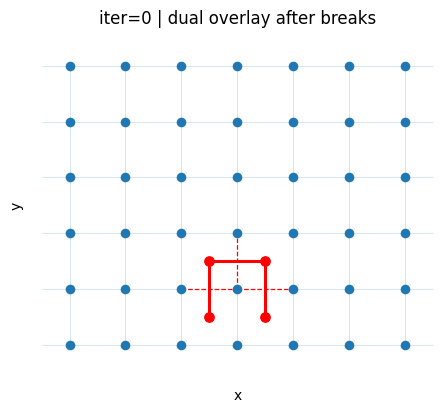

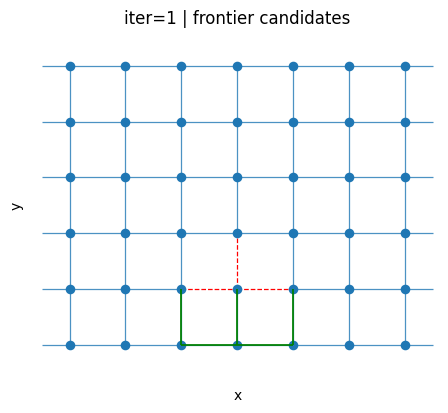

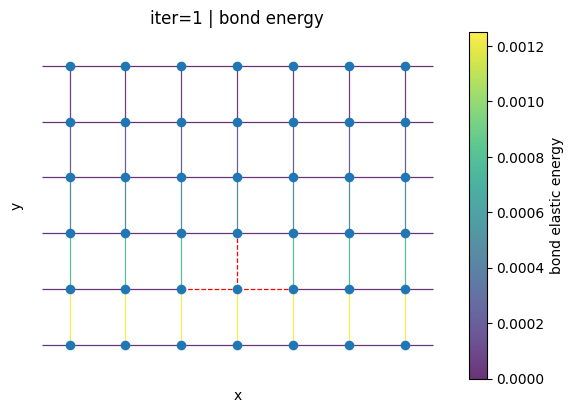

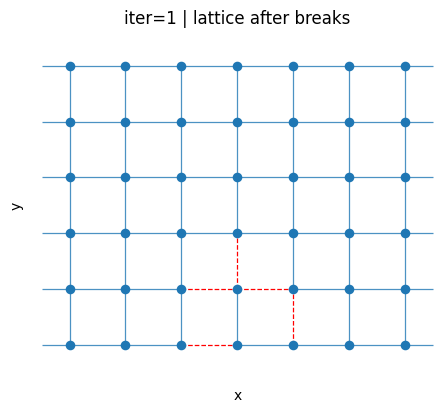

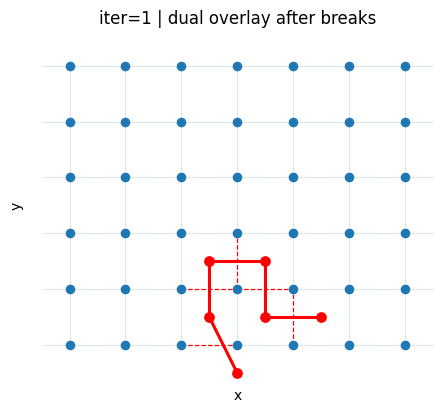

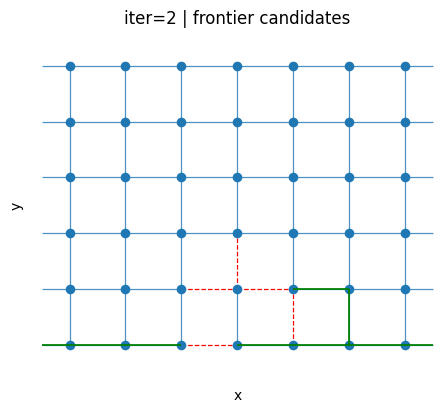

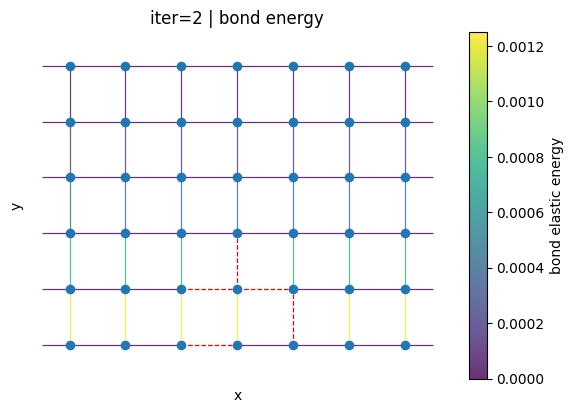

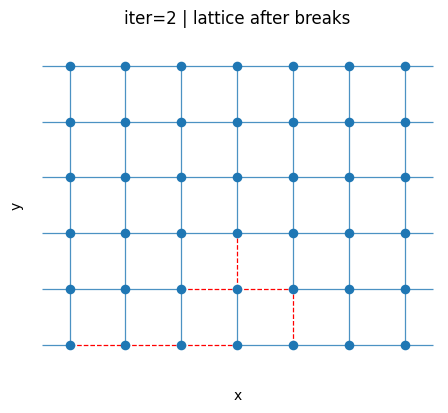

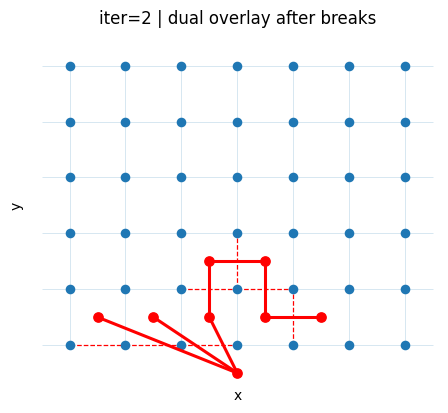

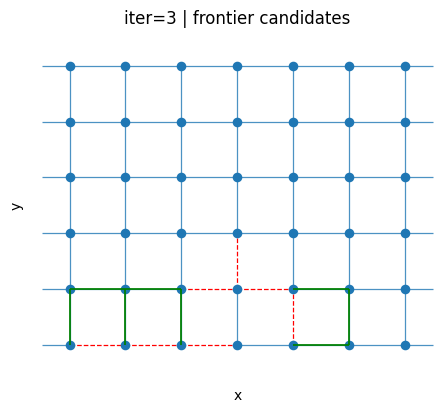

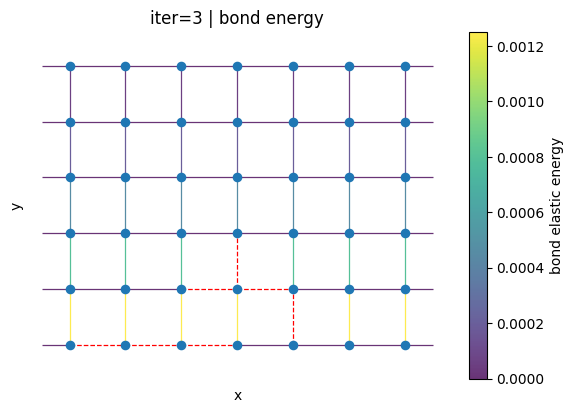

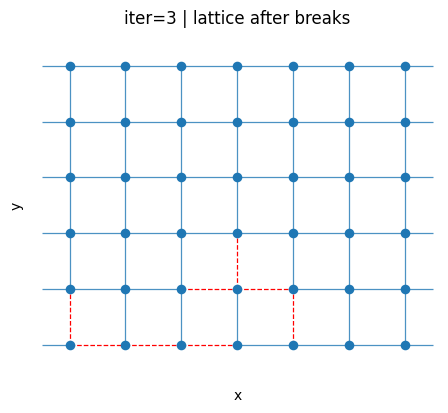

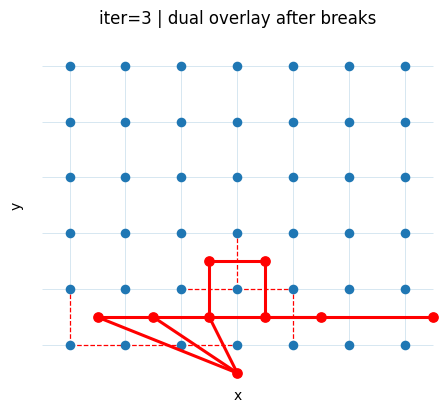

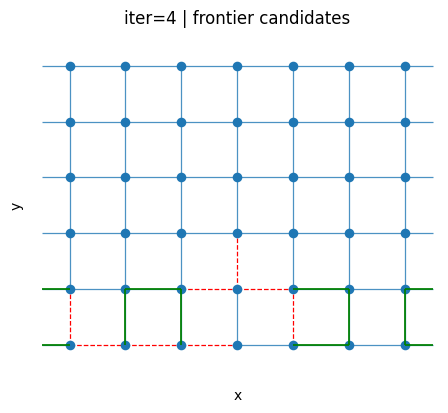

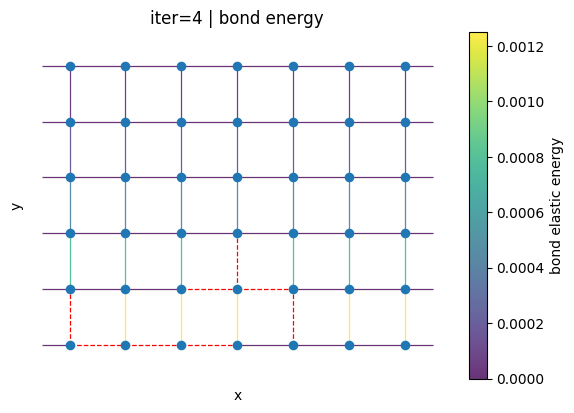

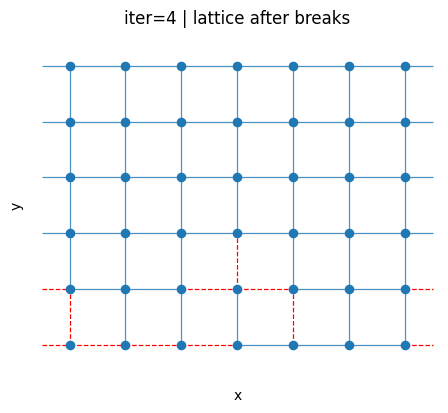

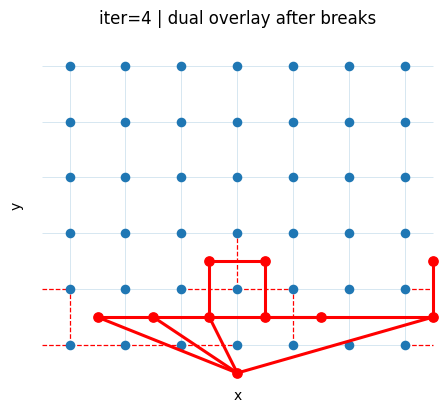

In [23]:
demo_trivial_evolution(mode="aer", iters=5, k_new=2, reps=2, shots=2048, beta=2.0)
